# ✈️ NASA C-MAPSS FD003 — EDA + 전처리 + Feature Engineering + Validation Split 파이프라인

**[FD003 No-Clustering / Sensor Override 적용 버전 — v2 수정본]**

공통 흐름: 센서 제거 기준 확정 → RUL cap → Gaussian smoothing → 엔진 단위 Validation 분리

분기 흐름:
- **ML 분기**: 시계열 파생변수 생성 → ML 전체 피처 기준 MinMax 정규화
- **DL 분기**: 원본 센서 기준 MinMax 정규화 → 슬라이딩 윈도우 생성

> **FD003 핵심 반영 사항**
> - 운전 조건: **1가지 (Sea Level)** — FD001과 동일
> - 고장 모드: **2개(HPC + Fan 열화)**
> - 센서 제거: 단순 STD 기준만 사용하지 않고, FD003 기준 수동 override 적용
>   - `s_6` 수동 제거
>   - `s_10` 수동 유지
> - FD001 제거 센서 비교 코드는 의사결정 로직에서 제거
> - DL에는 ML용 파생변수를 넣지 않고, 정규화된 raw sensor sequence만 사용

---

> **🔧 v2 수정 사항 (코드 리뷰 반영)**
>
> **[수정 1 — Cell 10. DL 슬라이딩 윈도우]** `y_test_dl` 오류 수정
> - 기존: 마지막 윈도우에만 실제 RUL, 나머지 윈도우는 전부 0
> - 수정: 각 엔진의 마지막 사이클 RUL을 기준으로 모든 윈도우에 `RUL + k` 역산 할당
> - 추가: sanity check 코드로 역산 정합성 자동 검증
>
> **[수정 2 — Cell 11. val_eval]** 역할 명시 및 사용 가이드 추가
> - val_eval은 테스트 조건 시뮬레이션용 **최종 평가셋** (early stopping 기준 아님)
> - 학습 루프 early stopping → `X_valid_dl` / `y_valid_dl` (전체 슬라이딩 윈도우)
> - 최종 RUL 예측 성능 리포팅 → `val_eval` (50~90% 절단, test 분포 모방)
> - 누수 없음 확인: 엔진 단위 split + subtrain 기준 scaler fit


## 0. 환경 설정

In [1]:
import sys, subprocess
for pkg in ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
print('✅ 라이브러리 설치 완료')

✅ 라이브러리 설치 완료


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp, kendalltau
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────────────────────
import logging
import matplotlib.font_manager as fm
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

def force_korean_font():
    system = platform.system()
    if system == "Windows":
        font_path = "C:/Windows/Fonts/malgun.ttf"
        font_name = "Malgun Gothic"
    elif system == "Darwin":
        font_path = "/System/Library/Fonts/AppleGothic.ttf"
        font_name = "AppleGothic"
    else:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        font_name = "NanumGothic"
        if not os.path.exists(font_path):
            os.system("apt-get update -qq")
            os.system("apt-get install -y fonts-nanum -qq")
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = font_name
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        print(f"✅ 한글 폰트 적용: {font_name}")
    else:
        print("❌ 폰트 못 찾음")

force_korean_font()

# ── 다크 테마 ─────────────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})
force_korean_font()

# ── 전역 상수 ─────────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
RUL_CAP      = 125
GAUSS_SIGMA  = 2
CONST_THR    = 0.01

TEMPORAL_LAGS      = [1, 3, 5]
TEMPORAL_DIFFS     = [1]
TEMPORAL_ROLLS     = [3, 5]
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS      = [5]

# ── 센서 분류 (EDA 시각화용 — 클러스터링과 무관)
FAN_SENSORS = ['s_1','s_6','s_8','s_13','s_15']
HPC_SENSORS = ['s_3','s_7','s_9','s_11','s_12']

WINDOW_SIZE = 30
STEP        = 1

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')
print(f'   Window={WINDOW_SIZE}')

✅ 한글 폰트 적용: Malgun Gothic
✅ 한글 폰트 적용: Malgun Gothic
✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01
   Window=30


## 1. 데이터 로딩 & 컬럼명 표준화

In [3]:
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData','./CMAPSSData','../CMAPSSData']:
    if os.path.exists(os.path.join(c,'train_FD003.txt')):
        DATA_DIR = c; break
else:
    print(f'❌ 경로 없음. 현재: {os.getcwd()}')

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD003.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD003.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD003.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print('✅ FD003 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD003 로딩 완료
   Train : (24720, 26)  |  엔진 100대
   Test  : (16596, 26)   |  엔진 100대
   RUL   : (100, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669


---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [4]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']].style
        .background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))
print('\n📌 CV ≈ 0 → 열화 정보 없음 → 제거 대상')
print('📌 FD003 주목: Fan 관련 센서(s_1, s_6, s_8, s_13, s_15)의 CV 확인 (FD001 대비 변동 증가 예상)')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,24720,0,0,0,100,✅ 정상
Test,16596,0,0,0,100,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,518.6700,0.0000,518.6700,518.6700,0.0000
s_2,642.4579,0.5230,640.8400,645.1100,0.0008
s_3,1588.0792,6.8104,1564.3000,1615.3900,0.0043
s_4,1404.4712,9.7732,1377.0600,1441.1600,0.0070
s_5,14.6200,0.0000,14.6200,14.6200,0.0000
s_6,21.5958,0.0181,21.4500,21.6100,0.0008
s_7,555.1438,3.4373,549.6100,570.4900,0.0062
s_8,2388.0716,0.1583,2386.9000,2388.6000,0.0001
s_9,9064.1108,19.9803,9017.9800,9234.3500,0.0022
s_10,1.3012,0.0035,1.2900,1.3200,0.0027



📌 CV ≈ 0 → 열화 정보 없음 → 제거 대상
📌 FD003 주목: Fan 관련 센서(s_1, s_6, s_8, s_13, s_15)의 CV 확인 (FD001 대비 변동 증가 예상)


### 2-2. 엔진 수명 분포

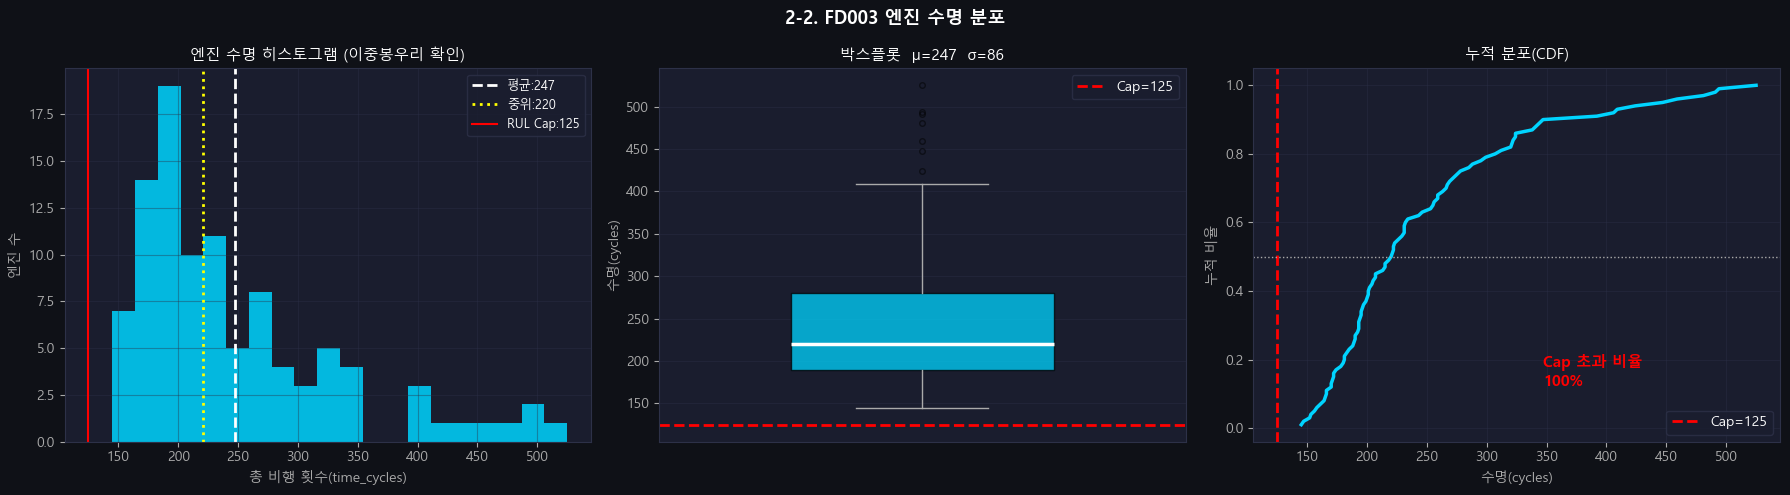


엔진 수명 통계:
  평균=247.2  중위=220.5  min=145  max=525
  Cap=125 초과 엔진: 100대 (100%)

📌 FD003: 수명 분포가 이중봉우리(bimodal)이면 두 고장 모드(HPC/Fan)의 수명 차이 가능성 시사


In [5]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD003 엔진 수명 분포', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)'); ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램 (이중봉우리 확인)')
ax.legend(fontsize=9)

ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([]); ax.legend()

ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)'); ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)'); ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 FD003: 수명 분포가 이중봉우리(bimodal)이면 두 고장 모드(HPC/Fan)의 수명 차이 가능성 시사')

### 2-3. 센서 분포 & 이상치 (전처리 전)

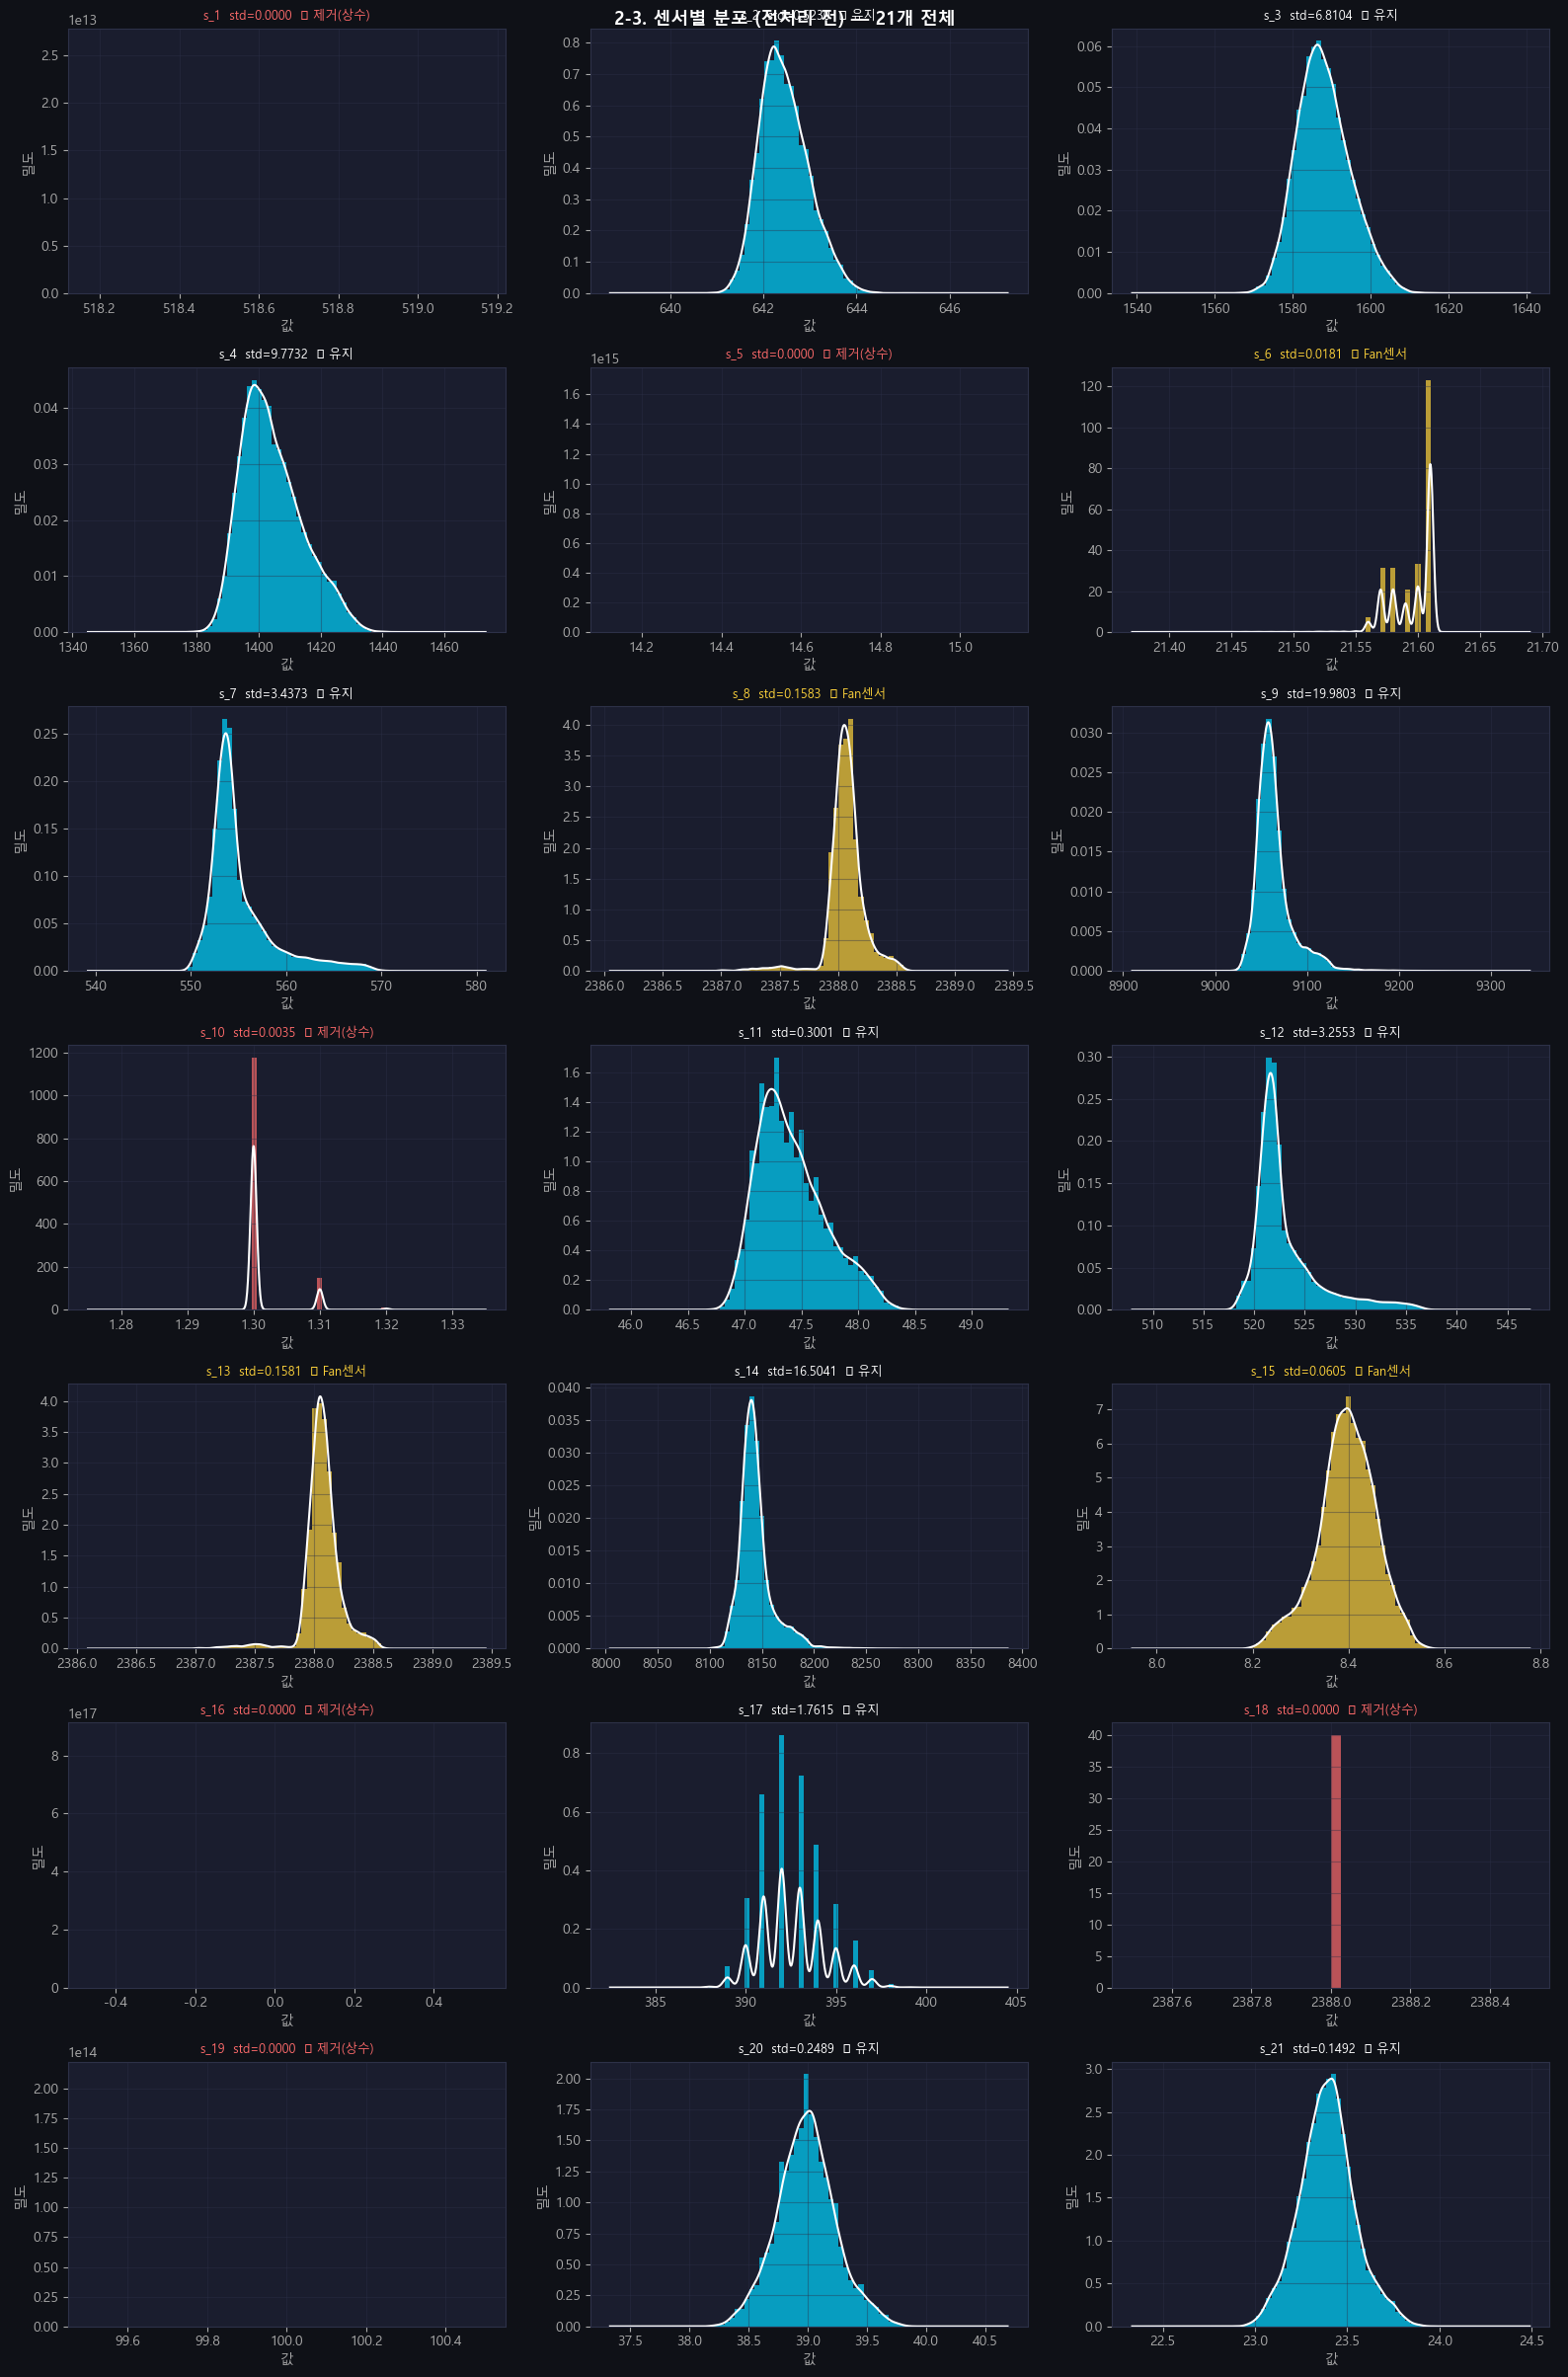

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
1,s_2,190,0.769
2,s_3,180,0.728
3,s_4,173,0.700
5,s_6,151,0.611
6,s_7,2188,8.851
7,s_8,1714,6.934
8,s_9,1844,7.460
9,s_10,2906,11.756
10,s_11,153,0.619
11,s_12,2276,9.207


In [6]:
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-3. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    is_fan   = s in FAN_SENSORS
    color = C[1] if is_const else (C[3] if is_fan else C[0])
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try: data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else ('🔶 Fan센서' if is_fan else '✅ 유지')
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else (C[3] if is_fan else WHITE))
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero): display(nonzero)
else: print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 2-4. 센서 간 상관관계 히트맵 (전처리 전)

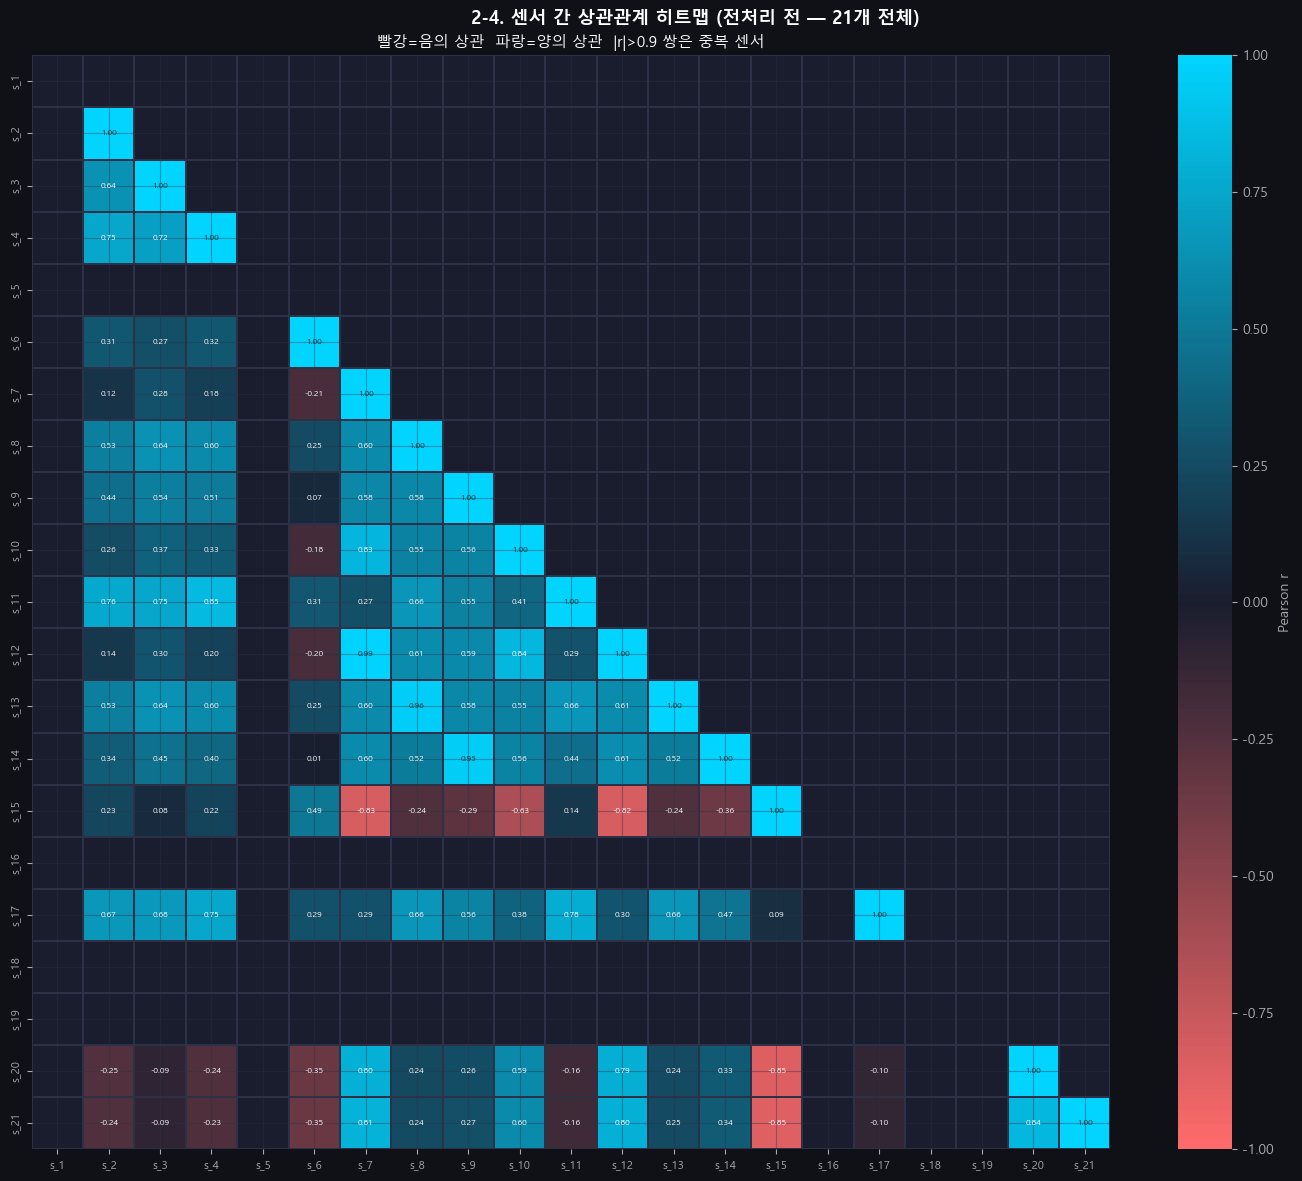

--- 고상관 센서 쌍 (|r| > 0.9): 3개 ---


,센서A,센서B,r
0,s_7,s_12,0.989
1,s_8,s_13,0.964
2,s_9,s_14,0.954


In [7]:
from matplotlib.colors import LinearSegmentedColormap
cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-4. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
print(f'--- 고상관 센서 쌍 (|r| > 0.9): {len(pairs)}개 ---')
if pairs: display(pd.DataFrame(pairs))
else: print('  해당 없음')

### 2-5. 센서별 열화 트렌드 (전처리 전)

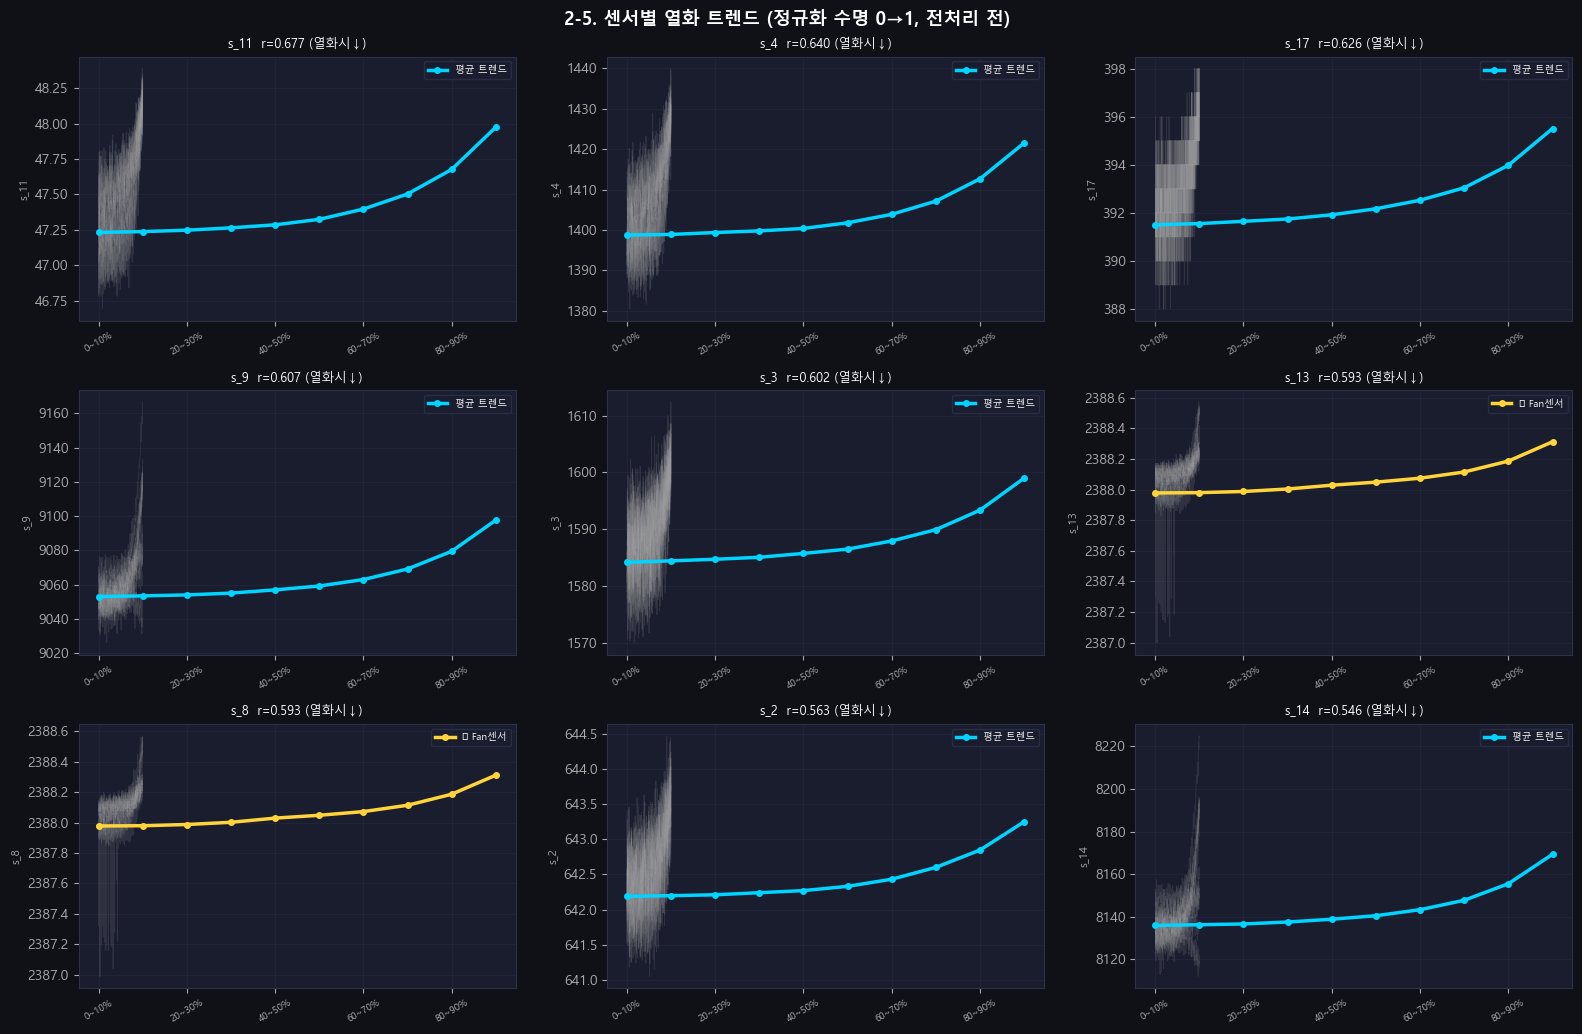

📌 r < 0: 엔진이 닳을수록 센서값 증가  |  r > 0: 감소
📌 노란색(🔶) = Fan 관련 센서 — FD001 대비 트렌드 변화 여부 주목


In [8]:
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.1].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]

n_cols = 3
n_rows = (len(trend_sensors)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-5. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

x_pos = range(len(labels))
sample_units = tr_trend['unit_nr'].unique()[:15]

for ax, s in zip(axes.flat, trend_sensors):
    is_fan = s in FAN_SENSORS
    for u in sample_units:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    color = C[3] if is_fan else C[0]
    ax.plot(x_pos, trend_mean[s].values, color=color, lw=2.5, marker='o', markersize=4,
            label=f'{"🔶 Fan센서" if is_fan else "평균 트렌드"}')
    r = corr_with_life[s]
    direction = '열화시↑' if r<0 else '열화시↓'
    ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
    ax.set_xticks(x_pos[::2])
    ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
    ax.set_ylabel(s, fontsize=8); ax.legend(fontsize=7)

for ax in axes.flat[len(trend_sensors):]: ax.set_visible(False)
plt.tight_layout(); plt.show()
print('📌 r < 0: 엔진이 닳을수록 센서값 증가  |  r > 0: 감소')
print('📌 노란색(🔶) = Fan 관련 센서 — FD001 대비 트렌드 변화 여부 주목')

### 2-6. RUL 상관계수 (전처리 전)

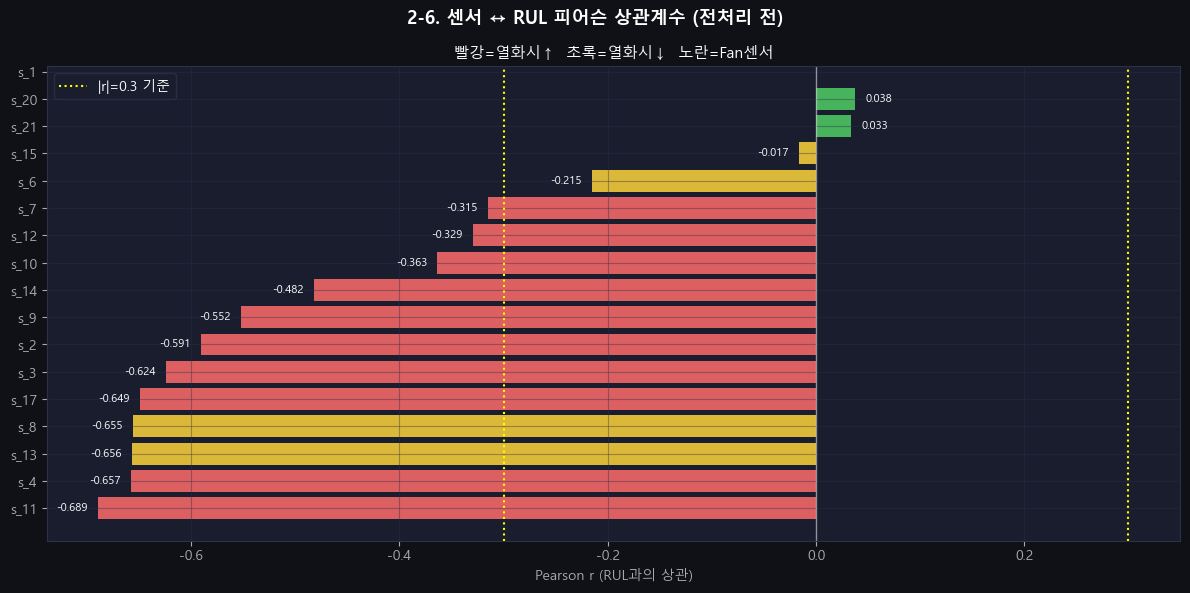

|r|>0.3 고상관 센서: 12개
  s_11: r=-0.689  🔵 HPC  Ps30 정적압력(psia)
  s_4: r=-0.657    T50 LPT 출구 온도(°R)
  s_13: r=-0.656  🔶 Fan  NRf 보정 팬 속도(rpm)
  s_8: r=-0.655  🔶 Fan  Nf 팬 속도(rpm)
  s_17: r=-0.649    htBleed 블리드 엔탈피
  s_3: r=-0.624  🔵 HPC  T30 HPC 출구 온도(°R)
  s_2: r=-0.591    T24 LPC 출구 온도(°R)
  s_9: r=-0.552  🔵 HPC  Nc 코어 속도(rpm)
  s_14: r=-0.482    NRc 보정 코어속도(rpm)
  s_10: r=-0.363    epr 엔진 압력비
  s_12: r=-0.329  🔵 HPC  phi 연료/Ps30 비율
  s_7: r=-0.315  🔵 HPC  P30 HPC 출구 압력(psia)


In [9]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-6. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[3] if s in FAN_SENSORS else (C[1] if v<0 else C[2])
              for s, v in rul_corr_before.items()]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시↑  초록=열화시↓  노란=Fan센서')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s, r in high_corr.sort_values(key=abs, ascending=False).items():
    tag = '🔶 Fan' if s in FAN_SENSORS else ('🔵 HPC' if s in HPC_SENSORS else '')
    print(f'  {s}: r={r:.3f}  {tag}  {SENSOR_DESC.get(s,"")[:30]}')

### 2-7. 시차상관관계 (Sensor → RUL, lag 0 ~ 15)

> **해석:** lag=k에서의 상관계수는 '현재 센서값이 k사이클 뒤의 RUL과 얼마나 관련되는가'를 의미.  
> FD003에서는 Fan 센서의 lag 패턴이 HPC 센서와 다를 수 있음 — 두 고장 모드의 조기 경보 타이밍 차이

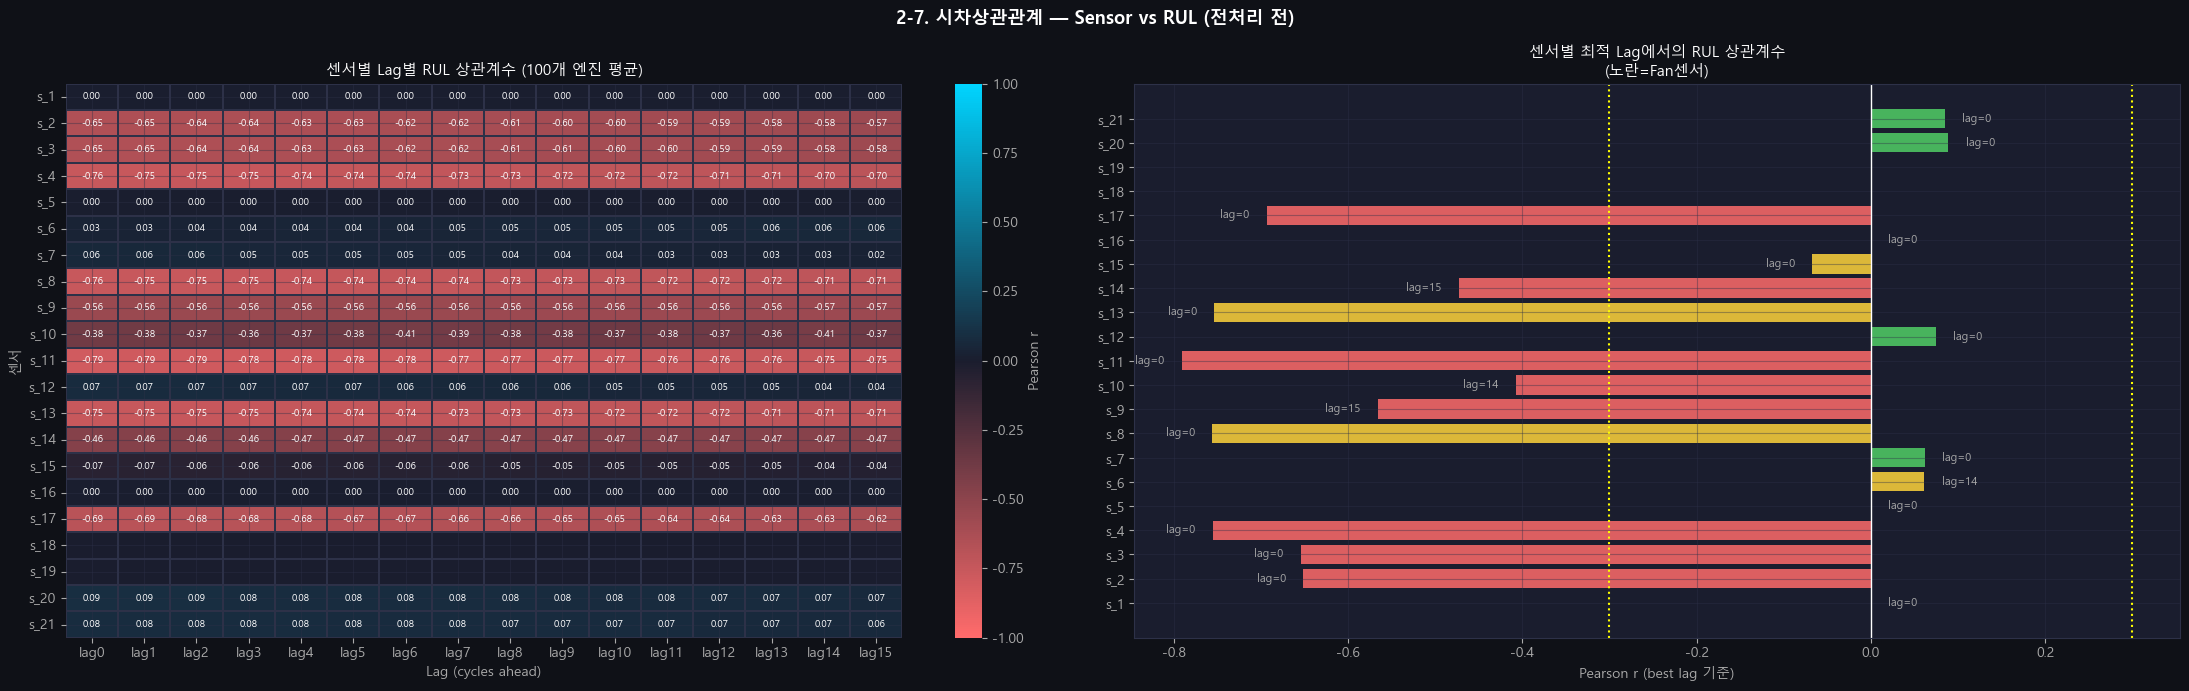

,최적 lag (cycles),상관계수 (r),조기경보 능력,센서 유형,센서 설명
센서,,,,,
s_1,0,0.0000,❌ 약함,🔶 Fan,T2 팬 입구 온도(°R)
s_2,0,-0.6511,✅ 강함,기타,T24 LPC 출구 온도(°R)
s_3,0,-0.6543,✅ 강함,🔵 HPC,T30 HPC 출구 온도(°R)
s_4,0,-0.7554,✅ 강함,기타,T50 LPT 출구 온도(°R)
s_5,0,0.0000,❌ 약함,기타,P2 팬 입구 압력(psia)
s_6,14,0.0611,❌ 약함,🔶 Fan,P15 바이패스 압력(psia)
s_7,0,0.0614,❌ 약함,🔵 HPC,P30 HPC 출구 압력(psia)
s_8,0,-0.7555,✅ 강함,🔶 Fan,Nf 팬 속도(rpm)
s_9,15,-0.5655,✅ 강함,🔵 HPC,Nc 코어 속도(rpm)


In [10]:
MAX_LAG = 15
LAGS    = list(range(0, MAX_LAG + 1))

lag_matrix = np.full((len(SENSOR_COLS), len(LAGS)), np.nan)

for si, s in enumerate(SENSOR_COLS):
    unit_lag_corrs = {lag: [] for lag in LAGS}
    for uid in tr_rul['unit_nr'].unique():
        udf    = tr_rul[tr_rul['unit_nr']==uid].sort_values('time_cycles')
        sensor = udf[s].values
        rul    = udf['RUL'].values
        for lag in LAGS:
            if len(sensor) > lag + 5:
                c = np.corrcoef(sensor[:len(sensor)-lag], rul[lag:])[0,1]
                if np.isfinite(c): unit_lag_corrs[lag].append(c)
    lag_matrix[si] = [np.mean(unit_lag_corrs[l]) if unit_lag_corrs[l] else np.nan for l in LAGS]

lag_df = pd.DataFrame(lag_matrix, index=SENSOR_COLS, columns=[f'lag{l}' for l in LAGS])

best_lag_idx, best_lag_corr = [], []
for i in range(len(SENSOR_COLS)):
    row = lag_matrix[i]
    if np.all(np.isnan(row)):
        best_lag_idx.append(0); best_lag_corr.append(np.nan)
    else:
        idx = int(np.nanargmax(np.abs(row)))
        best_lag_idx.append(idx); best_lag_corr.append(float(row[idx]))

best_lag_corr_plot = [v if np.isfinite(v) else 0.0 for v in best_lag_corr]

cmap_lag = LinearSegmentedColormap.from_list('lag', ['#ff6b6b','#1a1d2e','#00d4ff'], N=256)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle('2-7. 시차상관관계 — Sensor vs RUL (전처리 전)', fontsize=13, fontweight='bold')

sns.heatmap(lag_df, ax=axes[0], cmap=cmap_lag, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label':'Pearson r'})
axes[0].set_title('센서별 Lag별 RUL 상관계수 (100개 엔진 평균)')
axes[0].set_xlabel('Lag (cycles ahead)'); axes[0].set_ylabel('센서')

bar_colors = [GRAY if not np.isfinite(v) else (C[3] if SENSOR_COLS[i] in FAN_SENSORS
              else (C[1] if v<0 else C[2])) for i, v in enumerate(best_lag_corr)]
bars = axes[1].barh(SENSOR_COLS, best_lag_corr_plot, color=bar_colors, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].axvline(0.3, color='yellow', lw=1.5, ls=':')
axes[1].axvline(-0.3, color='yellow', lw=1.5, ls=':')
for bar, li, v in zip(bars, best_lag_idx, best_lag_corr):
    if not np.isfinite(v): continue
    x = bar.get_width()
    axes[1].text(x+(0.02 if x>=0 else -0.02), bar.get_y()+bar.get_height()/2,
                 f'lag={LAGS[li]}', va='center', ha='left' if x>=0 else 'right', fontsize=8, color=GRAY)
axes[1].set_title('센서별 최적 Lag에서의 RUL 상관계수\n(노란=Fan센서)')
axes[1].set_xlabel('Pearson r (best lag 기준)')
plt.tight_layout(); plt.show()

lag_summary = pd.DataFrame({
    '최적 lag (cycles)': [LAGS[i] for i in best_lag_idx],
    '상관계수 (r)'     : [round(v,4) if np.isfinite(v) else np.nan for v in best_lag_corr],
    '조기경보 능력'    : ['⬜ 상수센서' if not np.isfinite(v)
                         else ('✅ 강함' if abs(v)>=0.5 else ('🔶 보통' if abs(v)>=0.3 else '❌ 약함'))
                         for v in best_lag_corr],
    '센서 유형'        : ['🔶 Fan' if s in FAN_SENSORS else ('🔵 HPC' if s in HPC_SENSORS else '기타')
                         for s in SENSOR_COLS],
    '센서 설명'        : [SENSOR_DESC.get(s,s) for s in SENSOR_COLS],
}, index=SENSOR_COLS)
lag_summary.index.name = '센서'
display(lag_summary)

### 2-8. Mann-Kendall 트렌드 검정 (전처리 전)

> **원리:** 비모수 단조 트렌드 검정 — **유의 엔진 비율 ≥ 70%** → 열화 신호 안정 보유

In [11]:
print('=== 2-8. Mann-Kendall 트렌드 검정 (유의 엔진 비율) ===')

mk_rows = []
for s in SENSOR_COLS:
    sig_up, sig_dn, total = 0, 0, 0
    for uid in tr_rul['unit_nr'].unique():
        vals = tr_rul[tr_rul['unit_nr']==uid].sort_values('time_cycles')[s].values
        if len(vals) < 5: continue
        tau, p = kendalltau(np.arange(len(vals)), vals)
        total += 1
        if p < 0.05:
            if tau > 0: sig_up += 1
            else:       sig_dn += 1
    sig_pct = (sig_up+sig_dn)/total*100 if total else 0
    mk_rows.append({'센서':s, '상승 유의':sig_up, '하강 유의':sig_dn,
                    '유의 비율(%)':round(sig_pct,1),
                    '트렌드 방향':'↑ 증가' if sig_up>sig_dn else '↓ 감소',
                    '유용성':'✅ 유용' if sig_pct>=70 else '❌ 미약',
                    '센서 유형':'🔶 Fan' if s in FAN_SENSORS else ('🔵 HPC' if s in HPC_SENSORS else '기타')})

mk_df = pd.DataFrame(mk_rows).set_index('센서')
display(mk_df.style.background_gradient(subset=['유의 비율(%)'], cmap='YlGn'))
useful_mk = mk_df[mk_df['유용성']=='✅ 유용'].index.tolist()
print(f'\n유용 센서 (유의 비율≥70%): {len(useful_mk)}개')
print(f'  {useful_mk}')

=== 2-8. Mann-Kendall 트렌드 검정 (유의 엔진 비율) ===


,상승 유의,하강 유의,유의 비율(%),트렌드 방향,유용성,센서 유형
센서,,,,,,
s_1,0,0,0.000000,↓ 감소,❌ 미약,🔶 Fan
s_2,100,0,100.000000,↑ 증가,✅ 유용,기타
s_3,100,0,100.000000,↑ 증가,✅ 유용,🔵 HPC
s_4,100,0,100.000000,↑ 증가,✅ 유용,기타
s_5,0,0,0.000000,↓ 감소,❌ 미약,기타
s_6,27,23,50.000000,↑ 증가,❌ 미약,🔶 Fan
s_7,44,56,100.000000,↓ 감소,✅ 유용,🔵 HPC
s_8,100,0,100.000000,↑ 증가,✅ 유용,🔶 Fan
s_9,82,15,97.000000,↑ 증가,✅ 유용,🔵 HPC



유용 센서 (유의 비율≥70%): 14개
  ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


---
## 3. 결정 1 — 센서 제거 기준 확정

FD003은 FD001과 달리 Fan 열화가 포함되어 있으므로, FD001 제거 센서 목록을 그대로 비교 기준으로 쓰지 않는다.

이번 버전의 기준:
1. `std < CONST_THR`인 센서를 자동 제거 후보로 선정
2. FD003 검토 의견을 반영해 수동 override 적용
   - `s_6`: 수동 제거
   - `s_10`: 수동 유지
3. 최종 `REMOVE_SENSORS`, `USEFUL_SENSORS`를 이후 모든 ML/DL 전처리에서 공통 사용


=== 결정 1 — FD003 센서 제거 기준 확정 ===
표준편차 기준 자동 제거 후보 (std < 0.01): ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']  (6개)
수동 제거 센서: ['s_6']
수동 유지 센서: ['s_10']
최종 제거 센서: ['s_1', 's_5', 's_6', 's_16', 's_18', 's_19']  (6개)
최종 사용 센서: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']  (15개)


,std,자동제거후보,수동제거,수동유지,최종판정,유형
센서,,,,,,
s_1,0.000000e+00,O,X,X,❌ 제거,🔶 Fan
s_2,5.230311e-01,X,X,X,✅ 유지,기타
s_3,6.810418e+00,X,X,X,✅ 유지,🔵 HPC
s_4,9.773178e+00,X,X,X,✅ 유지,기타
s_5,3.552786e-15,O,X,X,❌ 제거,기타
s_6,1.811600e-02,X,O,X,❌ 제거,🔶 Fan
s_7,3.437343e+00,X,X,X,✅ 유지,🔵 HPC
s_8,1.582849e-01,X,X,X,✅ 유지,🔶 Fan
s_9,1.998029e+01,X,X,X,✅ 유지,🔵 HPC


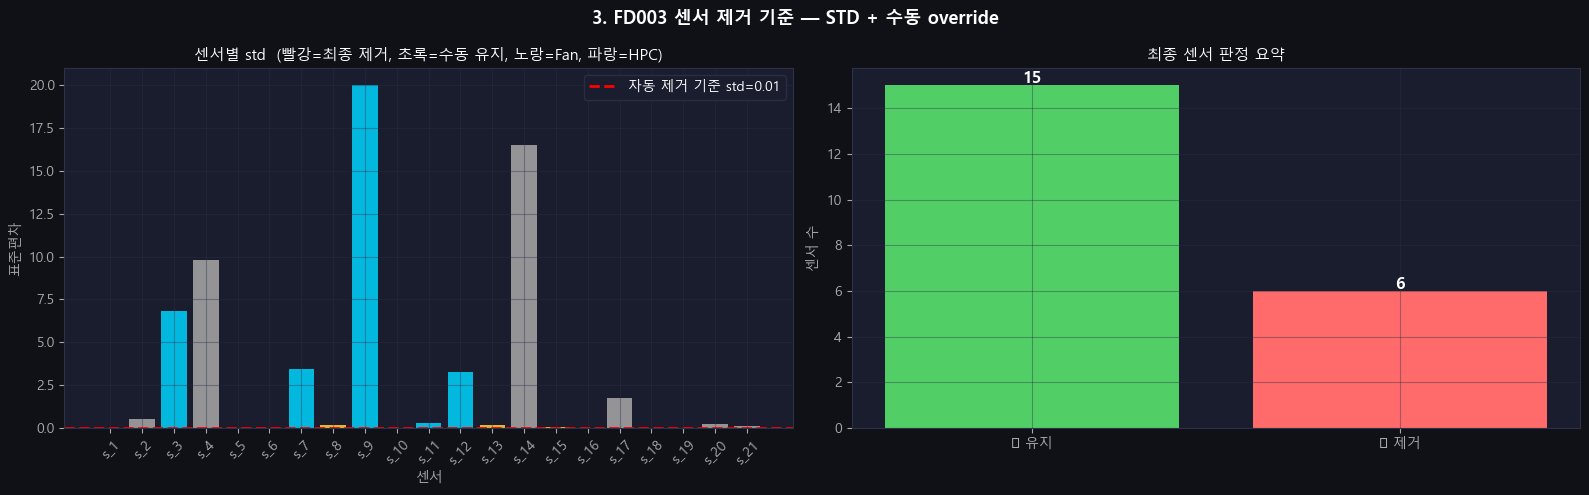


✅ 센서 제거 완료: 21개 → 15개
   이후 Gaussian, ML, DL 전처리는 모두 USEFUL_SENSORS 기준으로 진행합니다.


In [12]:
# ============================================================
# 결정 1 — FD003 센서 제거 기준 확정
# ============================================================

train_std = train_raw[SENSOR_COLS].std()
auto_remove_sensors = train_std[train_std < CONST_THR].index.tolist()

# FD003 검토 의견 반영
# - s_6 : STD만으로 남을 수 있어도 통계/트렌드 검토 기준으로 제거
# - s_10: STD 기준상 제거 후보가 되더라도 FD003에서는 유지
MANUAL_REMOVE_SENSORS = ['s_6']
MANUAL_KEEP_SENSORS   = ['s_10']

REMOVE_SENSORS = sorted(
    list((set(auto_remove_sensors) | set(MANUAL_REMOVE_SENSORS)) - set(MANUAL_KEEP_SENSORS)),
    key=lambda x: int(x.split('_')[1])
)

USEFUL_SENSORS = sorted(
    [s for s in SENSOR_COLS if s not in REMOVE_SENSORS],
    key=lambda x: int(x.split('_')[1])
)

print('=== 결정 1 — FD003 센서 제거 기준 확정 ===')
print(f'표준편차 기준 자동 제거 후보 (std < {CONST_THR}): {auto_remove_sensors}  ({len(auto_remove_sensors)}개)')
print(f'수동 제거 센서: {MANUAL_REMOVE_SENSORS}')
print(f'수동 유지 센서: {MANUAL_KEEP_SENSORS}')
print(f'최종 제거 센서: {REMOVE_SENSORS}  ({len(REMOVE_SENSORS)}개)')
print(f'최종 사용 센서: {USEFUL_SENSORS}  ({len(USEFUL_SENSORS)}개)')

# std 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('3. FD003 센서 제거 기준 — STD + 수동 override', fontsize=13, fontweight='bold')

colors_bar = []
for s in SENSOR_COLS:
    if s in REMOVE_SENSORS:
        colors_bar.append(C[1])   # 제거=빨강
    elif s in MANUAL_KEEP_SENSORS:
        colors_bar.append(C[2])   # 수동유지=초록
    elif s in FAN_SENSORS:
        colors_bar.append(C[3])   # Fan=노랑
    elif s in HPC_SENSORS:
        colors_bar.append(C[0])   # HPC=파랑
    else:
        colors_bar.append(GRAY)

axes[0].bar(SENSOR_COLS, train_std[SENSOR_COLS], color=colors_bar, alpha=0.85)
axes[0].axhline(CONST_THR, color='red', ls='--', lw=2, label=f'자동 제거 기준 std={CONST_THR}')
axes[0].set_xlabel('센서')
axes[0].set_ylabel('표준편차')
axes[0].set_title('센서별 std  (빨강=최종 제거, 초록=수동 유지, 노랑=Fan, 파랑=HPC)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

summary_data = pd.DataFrame({
    '센서': SENSOR_COLS,
    'std': train_std[SENSOR_COLS].values,
    '자동제거후보': ['O' if s in auto_remove_sensors else 'X' for s in SENSOR_COLS],
    '수동제거': ['O' if s in MANUAL_REMOVE_SENSORS else 'X' for s in SENSOR_COLS],
    '수동유지': ['O' if s in MANUAL_KEEP_SENSORS else 'X' for s in SENSOR_COLS],
    '최종판정': ['❌ 제거' if s in REMOVE_SENSORS else '✅ 유지' for s in SENSOR_COLS],
    '유형': ['🔶 Fan' if s in FAN_SENSORS else ('🔵 HPC' if s in HPC_SENSORS else '기타') for s in SENSOR_COLS]
}).set_index('센서')

display(summary_data)

decision_counts = summary_data['최종판정'].value_counts()
axes[1].bar(decision_counts.index, decision_counts.values, color=[C[2] if '유지' in x else C[1] for x in decision_counts.index])
axes[1].set_title('최종 센서 판정 요약')
axes[1].set_ylabel('센서 수')
for i, v in enumerate(decision_counts.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 원본에 적용
train_s1 = train_raw.drop(columns=REMOVE_SENSORS)
test_s1  = test_raw.drop(columns=REMOVE_SENSORS)

print(f'\n✅ 센서 제거 완료: {len(SENSOR_COLS)}개 → {len(USEFUL_SENSORS)}개')
print('   이후 Gaussian, ML, DL 전처리는 모두 USEFUL_SENSORS 기준으로 진행합니다.')


---
## 4. RUL 레이블 생성 & Cap 적용

**FD003 주목:** 두 고장 모드의 수명 분포 차이가 있을 경우 고장 모드별 cap을 검토  
기본값: cap=125 (FD001과 동일)

✅ RUL 레이블 생성 완료  |  cap=125
   Train RUL 범위: 0 ~ 125
   Test  RUL 범위: 6 ~ 145


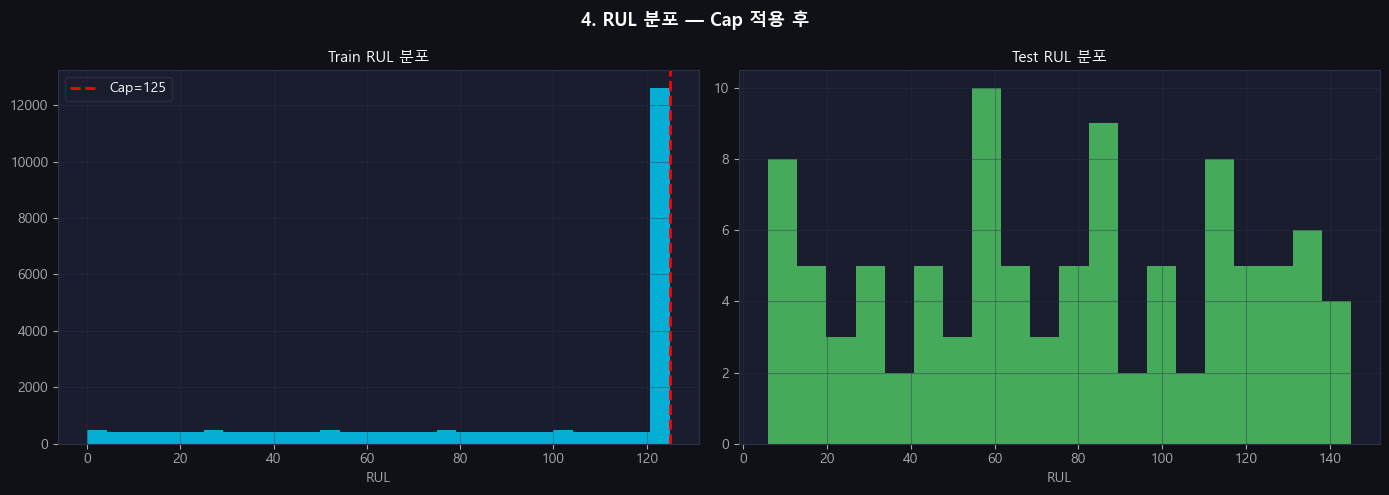

In [13]:
def add_rul(df, cap=None):
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL'] = df['max_c'] - df['time_cycles']
    if cap: df['RUL'] = df['RUL'].clip(upper=cap)
    return df.drop(columns='max_c')

train_s2 = add_rul(train_s1, cap=RUL_CAP)

# 테스트 RUL (마지막 행 + 실제 RUL)
test_last = test_s1.groupby('unit_nr').last().reset_index()
test_last['RUL'] = rul_df['RUL'].values

print(f'✅ RUL 레이블 생성 완료  |  cap={RUL_CAP}')
print(f'   Train RUL 범위: {train_s2["RUL"].min():.0f} ~ {train_s2["RUL"].max():.0f}')
print(f'   Test  RUL 범위: {test_last["RUL"].min():.0f} ~ {test_last["RUL"].max():.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('4. RUL 분포 — Cap 적용 후', fontsize=13, fontweight='bold')
axes[0].hist(train_s2['RUL'], bins=30, color=C[0], alpha=0.8, edgecolor='none')
axes[0].axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
axes[0].set_title('Train RUL 분포'); axes[0].set_xlabel('RUL'); axes[0].legend()
axes[1].hist(test_last['RUL'], bins=20, color=C[2], alpha=0.8, edgecolor='none')
axes[1].set_title('Test RUL 분포'); axes[1].set_xlabel('RUL')
plt.tight_layout(); plt.show()

---
## 6. Gaussian 스무딩 (σ=2)

엔진 단위 적용 — FD001과 동일.  
고장 모드별 노이즈 특성이 다를 경우 σ 조정 검토.

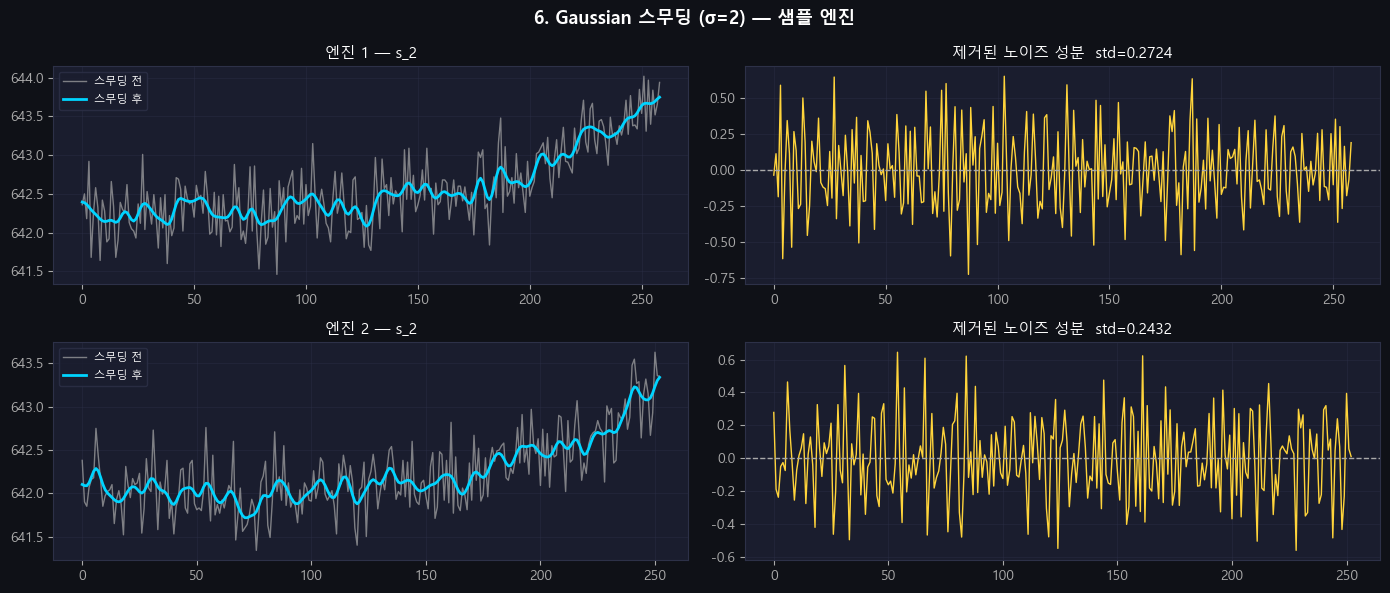

✅ Gaussian 스무딩 완료  |  σ=2


In [14]:
def apply_gaussian(df, sensors, sigma=2):
    df = df.copy()
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for s in sensors:
            df.loc[mask, s] = gaussian_filter1d(df.loc[mask, s].values, sigma=sigma)
    return df

train_s3 = apply_gaussian(train_s2, USEFUL_SENSORS, sigma=GAUSS_SIGMA)
test_s3  = apply_gaussian(test_s1,  USEFUL_SENSORS, sigma=GAUSS_SIGMA)

# 스무딩 효과 시각화 (샘플 엔진 2개)
sample_sensor = USEFUL_SENSORS[0] if USEFUL_SENSORS else 's_2'
sample_units  = train_s2['unit_nr'].unique()[:2]

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle(f'6. Gaussian 스무딩 (σ={GAUSS_SIGMA}) — 샘플 엔진', fontsize=13, fontweight='bold')

for row, u in enumerate(sample_units):
    before = train_s2[train_s2['unit_nr']==u][sample_sensor].values
    after  = train_s3[train_s3['unit_nr']==u][sample_sensor].values
    axes[row][0].plot(before, color=GRAY, alpha=0.7, lw=1, label='스무딩 전')
    axes[row][0].plot(after,  color=C[0], lw=2, label='스무딩 후')
    axes[row][0].set_title(f'엔진 {u} — {sample_sensor}')
    axes[row][0].legend(fontsize=8)
    diff = before - after
    axes[row][1].plot(diff, color=C[3], lw=1)
    axes[row][1].axhline(0, color=GRAY, ls='--', lw=1)
    axes[row][1].set_title(f'제거된 노이즈 성분  std={diff.std():.4f}')

plt.tight_layout(); plt.show()
print(f'✅ Gaussian 스무딩 완료  |  σ={GAUSS_SIGMA}')

---
## 7. Validation 분리 (엔진 단위 80:20, random_state=42)

FD001과 동일. 클러스터 비율을 유지하며 분리.

In [15]:
from sklearn.model_selection import train_test_split

all_units = train_s3['unit_nr'].unique()
subtrain_units, valid_units = train_test_split(all_units, test_size=0.2, random_state=42)

subtrain = train_s3[train_s3['unit_nr'].isin(subtrain_units)].reset_index(drop=True)
valid    = train_s3[train_s3['unit_nr'].isin(valid_units)  ].reset_index(drop=True)

print('✅ Validation 분리 완료')
print(f'   Sub-train: {subtrain.shape}  |  엔진 {subtrain["unit_nr"].nunique()}대')
print(f'   Validation: {valid.shape}   |  엔진 {valid["unit_nr"].nunique()}대')


✅ Validation 분리 완료
   Sub-train: (20012, 21)  |  엔진 80대
   Validation: (4708, 21)   |  엔진 20대


---
## 8. DL용 정규화 — 센서 원본값 기준 MinMax

DL은 ML용 파생변수를 사용하지 않는다.  
따라서 DL 분기는 `USEFUL_SENSORS`만 sub-train 기준으로 MinMax 정규화한 뒤 sliding window를 만든다.

ML 분기는 다음 단계에서 **파생변수 생성 후 전체 ML feature를 별도로 정규화**한다.


In [16]:
# ============================================================
# DL용 센서 정규화
# ============================================================
# DL 입력은 raw sensor sequence 중심이므로 USEFUL_SENSORS만 정규화한다.
# scaler는 sub-train에만 fit하고, validation/test/train 전체에는 transform만 적용한다.

sensor_scaler = MinMaxScaler()
sensor_scaler.fit(subtrain[USEFUL_SENSORS])

def normalize_sensor_only(df, sensors, sc):
    df = df.copy()
    df[sensors] = sc.transform(df[sensors])
    return df

subtrain_s4 = normalize_sensor_only(subtrain, USEFUL_SENSORS, sensor_scaler)
valid_s4    = normalize_sensor_only(valid,    USEFUL_SENSORS, sensor_scaler)
test_s4     = normalize_sensor_only(test_s3,  USEFUL_SENSORS, sensor_scaler)

# 분석/시각화 편의용 전체 train 정규화본
train_s4 = normalize_sensor_only(train_s3, USEFUL_SENSORS, sensor_scaler)

print('✅ DL용 센서 MinMax 정규화 완료 (sub-train 기준)')
print(f'   subtrain range: min={subtrain_s4[USEFUL_SENSORS].min().min():.4f}, '
      f'max={subtrain_s4[USEFUL_SENSORS].max().max():.4f}')
print(f'   valid range   : min={valid_s4[USEFUL_SENSORS].min().min():.4f}, '
      f'max={valid_s4[USEFUL_SENSORS].max().max():.4f}')
print(f'   test range    : min={test_s4[USEFUL_SENSORS].min().min():.4f}, '
      f'max={test_s4[USEFUL_SENSORS].max().max():.4f}')


✅ DL용 센서 MinMax 정규화 완료 (sub-train 기준)
   subtrain range: min=0.0000, max=1.0000
   valid range   : min=-0.0129, max=1.0272
   test range    : min=-0.0800, max=0.9495


---
## 9. ML 분기 — 시계열 파생변수 생성 후 ML 전체 feature 정규화

ML은 사람이 설계한 시계열 파생변수를 적극 활용한다.

이번 버전에서는 더 엄밀하게 다음 순서로 처리한다.

```text
엔진 단위 split 완료 데이터
→ lag / diff / rolling mean / rolling std / EMA 생성
→ sub-train 기준으로 ML 전체 feature MinMax fit
→ validation / test에는 transform만 적용
```

이렇게 하면 원본 센서뿐 아니라 파생변수까지 동일한 기준으로 정규화되어 Ridge/Lasso/ElasticNet 같은 선형 모델에도 더 안정적이다.


In [17]:
def build_ml_features(df, sensors, lags, diffs, rolls, roll_stds, emas):
    """엔진 단위 시계열 파생변수 생성

    주의
    ----
    - 입력 df는 Gaussian smoothing 이후, 아직 ML feature scaling 전 데이터 사용
    - groupby('unit_nr') 기준으로 shift/rolling을 계산해 엔진 간 누수를 방지
    - lag/diff 때문에 생기는 초반 NaN은 제거
    """
    df = df.copy().sort_values(['unit_nr', 'time_cycles']).reset_index(drop=True)

    for s in sensors:
        grp = df.groupby('unit_nr')[s]

        for l in lags:
            df[f'{s}_lag{l}'] = grp.shift(l)

        for d in diffs:
            df[f'{s}_diff{d}'] = grp.diff(d)

        for r in rolls:
            df[f'{s}_roll{r}'] = grp.transform(
                lambda x, r=r: x.rolling(r, min_periods=1).mean()
            )

        for r in roll_stds:
            df[f'{s}_rollstd{r}'] = grp.transform(
                lambda x, r=r: x.rolling(r, min_periods=1).std().fillna(0)
            )

        for e in emas:
            df[f'{s}_ema{e}'] = grp.transform(
                lambda x, e=e: x.ewm(span=e, adjust=False).mean()
            )

    df = df.dropna().reset_index(drop=True)
    return df


def get_ml_feature_cols(df):
    """모델 입력으로 사용할 ML feature 목록"""
    exclude = {'unit_nr', 'time_cycles', 'RUL', 'setting_1', 'setting_2', 'setting_3',
               'setting1', 'setting2', 'setting3', 'fault_mode_cluster'}
    return [c for c in df.columns if c not in exclude]


# 1) ML feature engineering은 정규화 전 smoothed split 데이터에서 수행
subtrain_ml_raw = build_ml_features(
    subtrain, USEFUL_SENSORS,
    TEMPORAL_LAGS, TEMPORAL_DIFFS,
    TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS
)

valid_ml_raw = build_ml_features(
    valid, USEFUL_SENSORS,
    TEMPORAL_LAGS, TEMPORAL_DIFFS,
    TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS
)

test_ml_raw = build_ml_features(
    test_s3, USEFUL_SENSORS,
    TEMPORAL_LAGS, TEMPORAL_DIFFS,
    TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS
)

ML_FEATURES = get_ml_feature_cols(subtrain_ml_raw)

# 2) ML 전체 feature 기준 scaler fit/transform
ml_scaler = MinMaxScaler()
ml_scaler.fit(subtrain_ml_raw[ML_FEATURES])

def normalize_ml_features(df, features, sc):
    df = df.copy()
    df[features] = sc.transform(df[features])
    return df

subtrain_ml = normalize_ml_features(subtrain_ml_raw, ML_FEATURES, ml_scaler)
valid_ml    = normalize_ml_features(valid_ml_raw,    ML_FEATURES, ml_scaler)
test_ml     = normalize_ml_features(test_ml_raw,     ML_FEATURES, ml_scaler)

print('✅ No-Clustering 버전')
print('✅ ML 파생변수 생성 → ML 전체 feature MinMax 정규화 완료')
print(f'   ML 피처 수: {len(ML_FEATURES)}개')
print(f'   Sub-train raw/scaled: {subtrain_ml_raw.shape} → {subtrain_ml.shape}')
print(f'   Validation raw/scaled: {valid_ml_raw.shape} → {valid_ml.shape}')
print(f'   Test raw/scaled: {test_ml_raw.shape} → {test_ml.shape}')
print(f'   ML feature range 확인 — subtrain min={subtrain_ml[ML_FEATURES].min().min():.4f}, '
      f'max={subtrain_ml[ML_FEATURES].max().max():.4f}')


✅ No-Clustering 버전
✅ ML 파생변수 생성 → ML 전체 feature MinMax 정규화 완료
   ML 피처 수: 150개
   Sub-train raw/scaled: (19612, 156) → (19612, 156)
   Validation raw/scaled: (4608, 156) → (4608, 156)
   Test raw/scaled: (16096, 155) → (16096, 155)
   ML feature range 확인 — subtrain min=0.0000, max=1.0000


---
## 10. DL 분기 — 슬라이딩 윈도우 (window=30)

DL은 ML용 rolling/diff/lag/EMA 파생변수를 사용하지 않는다.  
입력은 `USEFUL_SENSORS`의 정규화된 raw sequence이며, window 단위로 3D 입력을 구성한다.

### 🔧 v2 수정: y_test_dl 레이블 할당
마지막 윈도우(절단 시점) RUL을 기준으로 모든 윈도우에 `actual_rul + k` 역산 할당.

### 🔧 v3 추가 수정: 평가 프로토콜 & sample_id 추적

**문제 1 — C-MAPSS 공식 평가 프로토콜**  
C-MAPSS 평가는 각 엔진의 **마지막 윈도우 하나**의 예측값만 사용한다.  
전체 윈도우 대상으로 RMSE를 계산하면 공식 평가와 다른 결과가 나온다.

**문제 2 — sample_id가 엔진 ID가 아님**  
기존 `sample_id`는 단순 윈도우 순번(0, 1, 2, ...)이라 저장된 CSV에서  
"어느 엔진의 마지막 윈도우"인지 추적이 불가능했다.

**해결**  
- `make_sliding_windows` 반환값에 `unit_ids` (엔진 번호), `is_last` (마지막 윈도우 여부) 추가  
- `get_last_window_eval()` 헬퍼로 평가용 마지막 윈도우만 추출  
- `to_long_format`에도 `unit_nr`, `is_last` 컬럼 포함

### val_eval과의 역할 분리

| 데이터 | 목적 |
|---|---|
| `X_valid_dl`, `y_valid_dl` | 학습 루프 loss 모니터링, **early stopping 기준** |
| `val_eval` (Cell 11) | 테스트 조건 모방 **최종 성능 평가** (학습에 사용 금지) |


In [18]:
DL_FEATURES = USEFUL_SENSORS.copy()
print('✅ fault_mode_cluster 미포함 (No-Clustering 버전)')


# ════════════════════════════════════════════════════════════════════════════
# make_sliding_windows  (v3: unit_ids + is_last 반환 추가)
# ════════════════════════════════════════════════════════════════════════════
def make_sliding_windows(df, features, window=30, step=1):
    """슬라이딩 윈도우 생성

    Returns
    -------
    X        : (N, window, F)  입력 시퀀스
    y        : (N,)            RUL 레이블
    sid      : (N,)            윈도우 순번 (0-based)
    unit_ids : (N,)            엔진 번호  → CSV 저장 및 평가 필터링에 사용
    is_last  : (N,)            True = 해당 엔진의 마지막 윈도우
                               → C-MAPSS 공식 평가 시 이 플래그로 필터링
    """
    X_list, y_list, sid, uid_list, last_list = [], [], [], [], []
    sample_id = 0
    has_rul = 'RUL' in df.columns

    for uid in sorted(df['unit_nr'].unique()):
        sub = df[df['unit_nr'] == uid].sort_values('time_cycles')
        arr = sub[features].values
        rul = sub['RUL'].values if has_rul else np.zeros(len(sub))

        starts = list(range(0, len(arr) - window + 1, step))
        n_win  = len(starts)

        for win_idx, start in enumerate(starts):
            X_list.append(arr[start:start + window])
            y_list.append(rul[start + window - 1])
            sid.append(sample_id)
            uid_list.append(uid)
            last_list.append(win_idx == n_win - 1)  # 마지막 윈도우 여부
            sample_id += 1

    return (
        np.array(X_list),
        np.array(y_list),
        np.array(sid),
        np.array(uid_list),
        np.array(last_list),
    )


# ════════════════════════════════════════════════════════════════════════════
# 윈도우 생성
# ════════════════════════════════════════════════════════════════════════════
X_subtrain_dl, y_subtrain_dl, sid_sub, uid_sub, last_sub = \
    make_sliding_windows(subtrain_s4, DL_FEATURES, WINDOW_SIZE, STEP)

X_valid_dl, y_valid_dl, sid_val, uid_val, last_val = \
    make_sliding_windows(valid_s4, DL_FEATURES, WINDOW_SIZE, STEP)

# test: RUL 컬럼 없음 → y는 임시 zeros, 이후 역산으로 덮어씀
X_test_dl, _, sid_te, uid_te, last_te = \
    make_sliding_windows(test_s4, DL_FEATURES, WINDOW_SIZE, STEP)


# ════════════════════════════════════════════════════════════════════════════
# y_test_dl — 모든 윈도우에 RUL 역산 할당  (v2 수정)
#
# 마지막에서 k번째 윈도우의 RUL = actual_rul + k
#   마지막 윈도우 (k=0): actual_rul        ← 절단 시점
#   직전 윈도우   (k=1): actual_rul + 1
#   두 번째 이전  (k=2): actual_rul + 2  ...
# ════════════════════════════════════════════════════════════════════════════
test_units_sorted = sorted(test_s4['unit_nr'].unique())
y_test_dl = np.zeros(len(sid_te))
cursor = 0
for i, uid in enumerate(test_units_sorted):
    sub   = test_s4[test_s4['unit_nr'] == uid]
    n_win = max(0, len(sub) - WINDOW_SIZE + 1)
    if n_win > 0 and i < len(rul_df):
        actual_rul = rul_df['RUL'].iloc[i]
        for k in range(n_win):
            y_test_dl[cursor + (n_win - 1 - k)] = actual_rul + k
    cursor += n_win


# ── Sanity Check ─────────────────────────────────────────────────────────
cursor = 0
_errors = []
for i, uid in enumerate(test_units_sorted):
    sub   = test_s4[test_s4['unit_nr'] == uid]
    n_win = max(0, len(sub) - WINDOW_SIZE + 1)
    if n_win > 0 and i < len(rul_df):
        actual_rul = rul_df['RUL'].iloc[i]
        if abs(y_test_dl[cursor + n_win - 1] - actual_rul) > 1e-6:
            _errors.append(f'엔진 {uid}: last={y_test_dl[cursor+n_win-1]:.1f} (기대 {actual_rul:.1f})')
        if abs(y_test_dl[cursor] - (actual_rul + n_win - 1)) > 1e-6:
            _errors.append(f'엔진 {uid}: first={y_test_dl[cursor]:.1f} (기대 {actual_rul+n_win-1:.1f})')
    cursor += n_win

if _errors:
    print('❌ Sanity Check 실패:')
    for e in _errors: print(f'   {e}')
else:
    print('✅ y_test_dl Sanity Check 통과 — 모든 윈도우 RUL 역산 정합성 확인')


# ════════════════════════════════════════════════════════════════════════════
# get_last_window_eval — C-MAPSS 공식 평가용 헬퍼  (v3 신규)
#
# C-MAPSS 평가 프로토콜: 엔진당 마지막 윈도우 하나의 예측값만 사용
# 전체 윈도우 대상 RMSE ≠ 공식 평가 결과 → 반드시 last_window만 추출할 것
# ════════════════════════════════════════════════════════════════════════════
def get_last_window_eval(X, y, is_last):
    """is_last 플래그 기준으로 마지막 윈도우만 추출

    사용 예시 (모델 학습 후)
    -----------------------
    X_eval, y_eval = get_last_window_eval(X_test_dl, y_test_dl, last_te)
    y_pred = model.predict(X_eval)          # 엔진별 마지막 윈도우 예측
    rmse   = np.sqrt(mean_squared_error(y_eval, y_pred))  # 공식 평가 기준
    """
    return X[is_last], y[is_last]

X_test_last, y_test_last = get_last_window_eval(X_test_dl, y_test_dl, last_te)
X_valid_last, y_valid_last = get_last_window_eval(X_valid_dl, y_valid_dl, last_val)

print(f'\n✅ DL 슬라이딩 윈도우 완료  |  window={WINDOW_SIZE}  step={STEP}')
print(f'   DL 피처 수      : {len(DL_FEATURES)}개')
print(f'   Sub-train       : X={X_subtrain_dl.shape}  y={y_subtrain_dl.shape}')
print(f'   Validation 전체 : X={X_valid_dl.shape}    y={y_valid_dl.shape}  ← early stopping 기준')
print(f'   Validation 마지막: X={X_valid_last.shape}  y={y_valid_last.shape}  ← 공식 평가 기준')
print(f'   Test 전체       : X={X_test_dl.shape}    y={y_test_dl.shape}')
print(f'   Test 마지막     : X={X_test_last.shape}   y={y_test_last.shape}   ← 공식 평가 기준')
print(f'   Test y 범위     : min={y_test_dl.min():.1f}  max={y_test_dl.max():.1f}')


# ════════════════════════════════════════════════════════════════════════════
# Long Format CSV 저장용 변환  (v3: unit_nr, is_last 컬럼 추가)
# ════════════════════════════════════════════════════════════════════════════
def to_long_format(X, y, sid, uid_ids, is_last_flags, features):
    """3D 윈도우 배열 → long format DataFrame

    컬럼
    ----
    sample_id : 윈도우 순번
    unit_nr   : 엔진 번호  (평가 시 엔진 단위 필터링 가능)
    is_last   : 마지막 윈도우 여부  (공식 평가 필터링용)
    timestep  : 윈도우 내 타임스텝 (0 ~ window-1)
    ..sensors : 정규화된 센서값
    RUL       : 해당 윈도우의 RUL 레이블
    """
    rows = []
    for xi, yi, si, ui, li in zip(X, y, sid, uid_ids, is_last_flags):
        for t in range(xi.shape[0]):
            row = {'sample_id': int(si), 'unit_nr': int(ui),
                   'is_last': bool(li), 'timestep': t}
            for j, f in enumerate(features):
                row[f] = xi[t, j]
            row['RUL'] = yi
            rows.append(row)
    return pd.DataFrame(rows)


dl_subtrain_long = to_long_format(
    X_subtrain_dl, y_subtrain_dl, sid_sub, uid_sub, last_sub, DL_FEATURES)
dl_valid_long = to_long_format(
    X_valid_dl, y_valid_dl, sid_val, uid_val, last_val, DL_FEATURES)
dl_test_long = to_long_format(
    X_test_dl, y_test_dl, sid_te, uid_te, last_te, DL_FEATURES)

print(f'\n   DL long format — subtrain : {dl_subtrain_long.shape}')
print(f'   DL long format — valid    : {dl_valid_long.shape}')
print(f'   DL long format — test     : {dl_test_long.shape}')
print(f'\n📌 평가 가이드:')
print(f'   - early stopping   → X_valid_dl / y_valid_dl  (전체 윈도우)')
print(f'   - 공식 RMSE 평가   → X_test_last / y_test_last  (is_last=True 필터)')
print(f'   - CSV 기반 평가    → dl_test_long[dl_test_long.is_last == True]')


✅ fault_mode_cluster 미포함 (No-Clustering 버전)
✅ y_test_dl Sanity Check 통과 — 모든 윈도우 RUL 역산 정합성 확인

✅ DL 슬라이딩 윈도우 완료  |  window=30  step=1
   DL 피처 수      : 15개
   Sub-train       : X=(17692, 30, 15)  y=(17692,)
   Validation 전체 : X=(4128, 30, 15)    y=(4128,)  ← early stopping 기준
   Validation 마지막: X=(20, 30, 15)  y=(20,)  ← 공식 평가 기준
   Test 전체       : X=(13696, 30, 15)    y=(13696,)
   Test 마지막     : X=(100, 30, 15)   y=(100,)   ← 공식 평가 기준
   Test y 범위     : min=6.0  max=454.0

   DL long format — subtrain : (530760, 20)
   DL long format — valid    : (123840, 20)
   DL long format — test     : (410880, 20)

📌 평가 가이드:
   - early stopping   → X_valid_dl / y_valid_dl  (전체 윈도우)
   - 공식 RMSE 평가   → X_test_last / y_test_last  (is_last=True 필터)
   - CSV 기반 평가    → dl_test_long[dl_test_long.is_last == True]


---
## 11. val_eval 생성 (수명 50~90% 절단)

### 목적 및 역할 명시 (v2 수정)

val_eval은 **테스트 조건 시뮬레이션을 위한 최종 평가셋**이다.

C-MAPSS 테스트 셋 구조:
- 각 엔진의 시계열이 고장 전 임의의 시점에서 **절단**되어 있음
- 우리는 그 절단 시점의 RUL 하나만 예측하면 됨

validation 전체 슬라이딩 윈도우(`y_valid_dl`)는 엔진이 고장까지 가는 전체 궤적이므로 **테스트 조건과 분포가 다르다**.  
val_eval은 validation 엔진의 50~90% 시점에서 절단해 이 갭을 해소한다.

### 역할 분리 원칙

| 데이터셋 | 역할 | 사용 시점 |
|---|---|---|
| `X_valid_dl` / `y_valid_dl` | loss 모니터링, **early stopping** | 매 epoch |
| `val_eval_ml` / `dl_val_eval_long` | **최종 RUL 성능 리포팅** (test 조건 모방) | 학습 완료 후 |

> ⚠️ **주의**: val_eval을 early stopping 기준으로 사용하면, 사실상 test 조건에 과적합될 위험이 있음.

### 누수(Leakage) 여부 확인

| 검토 항목 | 결과 |
|---|---|
| val_eval 엔진이 subtrain에 포함? | ❌ 엔진 단위 split으로 완전 분리됨 |
| scaler가 valid 데이터로 fit? | ❌ subtrain만으로 fit |
| val_eval이 학습 루프에 개입? | 아래 사용 원칙 준수 시 없음 |

**누수 없음** — 단, val_eval을 early stopping 등 학습 결정에 사용하는 순간 test-proxy leakage 발생.


In [19]:
def make_val_eval(df_ml, df_dl, features_ml, features_dl, window,
                  cut_low=0.5, cut_high=0.9, random_state=42):
    """수명 50~90% 사이에서 절단 — test와 유사한 RUL 분포 생성

    ⚠️  사용 목적: 학습 완료 후 '최종 성능 평가'에만 사용할 것.
        early stopping / 하이퍼파라미터 튜닝 기준으로 쓰면
        val_eval이 사실상 두 번째 test set이 되어 낙관적 편향 발생.

    누수 없음 확인:
        - val_eval은 valid 엔진(subtrain과 분리된 엔진)에서만 생성
        - scaler는 subtrain 기준 fit → val_eval에는 transform만 적용됨

    Parameters
    ----------
    df_ml       : valid_ml  — ML 파생변수 포함 (lag/diff/roll/ema)
    df_dl       : valid_s4  — DL 슬라이딩 윈도우용 정규화 원본
    features_ml : ML_FEATURES
    features_dl : DL_FEATURES
    cut_low     : 절단 구간 하한 (기본 50% 수명)
    cut_high    : 절단 구간 상한 (기본 90% 수명)
    """
    rng = np.random.RandomState(random_state)
    ml_rows, dl_rows = [], []

    common_units = sorted(set(df_ml['unit_nr'].unique()) & set(df_dl['unit_nr'].unique()))

    for uid in common_units:
        sub_ml = df_ml[df_ml['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
        sub_dl = df_dl[df_dl['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)

        n_ml, n_dl = len(sub_ml), len(sub_dl)
        if n_ml < 2 or n_dl < window:
            continue

        # cut point 결정 (ML 행 기준, 수명의 cut_low ~ cut_high 사이 랜덤)
        cut_i = rng.randint(max(1, int(n_ml * cut_low)), int(n_ml * cut_high) + 1)
        cut_i = max(1, min(cut_i, n_ml))

        # ML: cut point 행의 피처 추출 (점 예측 평가용)
        ml_cols = [c for c in ['unit_nr', 'time_cycles'] + features_ml + ['RUL']
                   if c in sub_ml.columns and c != 'fault_mode_cluster']
        row_ml = sub_ml.iloc[cut_i - 1][ml_cols].to_dict()
        ml_rows.append(row_ml)

        # DL: cut point 비율에 대응하는 dl 인덱스로 window 슬라이스 추출
        cut_ratio = (cut_i - 1) / max(n_ml - 1, 1)
        cut_dl    = max(window, min(int(cut_ratio * n_dl) + 1, n_dl))
        seg       = sub_dl.iloc[cut_dl - window : cut_dl]

        if len(seg) == window:
            rul_at_cut = sub_ml.iloc[cut_i - 1]['RUL']
            for t_i, (_, r) in enumerate(seg.iterrows()):
                dr = {'sample_id': uid, 'timestep': t_i}
                for f in features_dl:
                    dr[f] = r[f] if f in r.index else np.nan
                dr['RUL'] = rul_at_cut
                dl_rows.append(dr)

    return pd.DataFrame(ml_rows), pd.DataFrame(dl_rows)


# ── val_eval 생성 ─────────────────────────────────────────────────────────
# valid_ml  → ML 파생변수 포함 (lag/roll/ema 존재)
# valid_s4  → DL 슬라이딩 윈도우용 정규화 원본 (USEFUL_SENSORS)
#
# ⚠️  이 결과는 학습 루프 outside에서 최종 평가에만 사용할 것.
#     early stopping 기준: X_valid_dl / y_valid_dl (전체 슬라이딩 윈도우) 사용.
val_eval_ml, dl_val_eval_long = make_val_eval(
    valid_ml, valid_s4, ML_FEATURES, DL_FEATURES, WINDOW_SIZE)

y_ve = val_eval_ml['RUL'].values if 'RUL' in val_eval_ml.columns else np.array([])

print('✅ val_eval 생성 완료')
print(f'   ML val_eval shape : {val_eval_ml.shape}')
print(f'   DL val_eval shape : {dl_val_eval_long.shape}')
if len(y_ve):
    print(f'   val_eval RUL 분포: μ={y_ve.mean():.1f}  min={y_ve.min():.0f}  max={y_ve.max():.0f}')

# ── 역할 구분 리마인더 출력 ──────────────────────────────────────────────────
print('\n📌 사용 가이드:')
print('   [학습 루프 중] early stopping → X_valid_dl / y_valid_dl (전체 슬라이딩 윈도우)')
print('   [학습 완료 후] 성능 리포팅   → val_eval_ml / dl_val_eval_long (절단본)')


✅ val_eval 생성 완료
   ML val_eval shape : (20, 153)
   DL val_eval shape : (600, 18)
   val_eval RUL 분포: μ=65.8  min=16  max=114

📌 사용 가이드:
   [학습 루프 중] early stopping → X_valid_dl / y_valid_dl (전체 슬라이딩 윈도우)
   [학습 완료 후] 성능 리포팅   → val_eval_ml / dl_val_eval_long (절단본)


---
## 12. 전처리 후 검증

### 12-1. 센서 상관관계 전처리 전후 비교

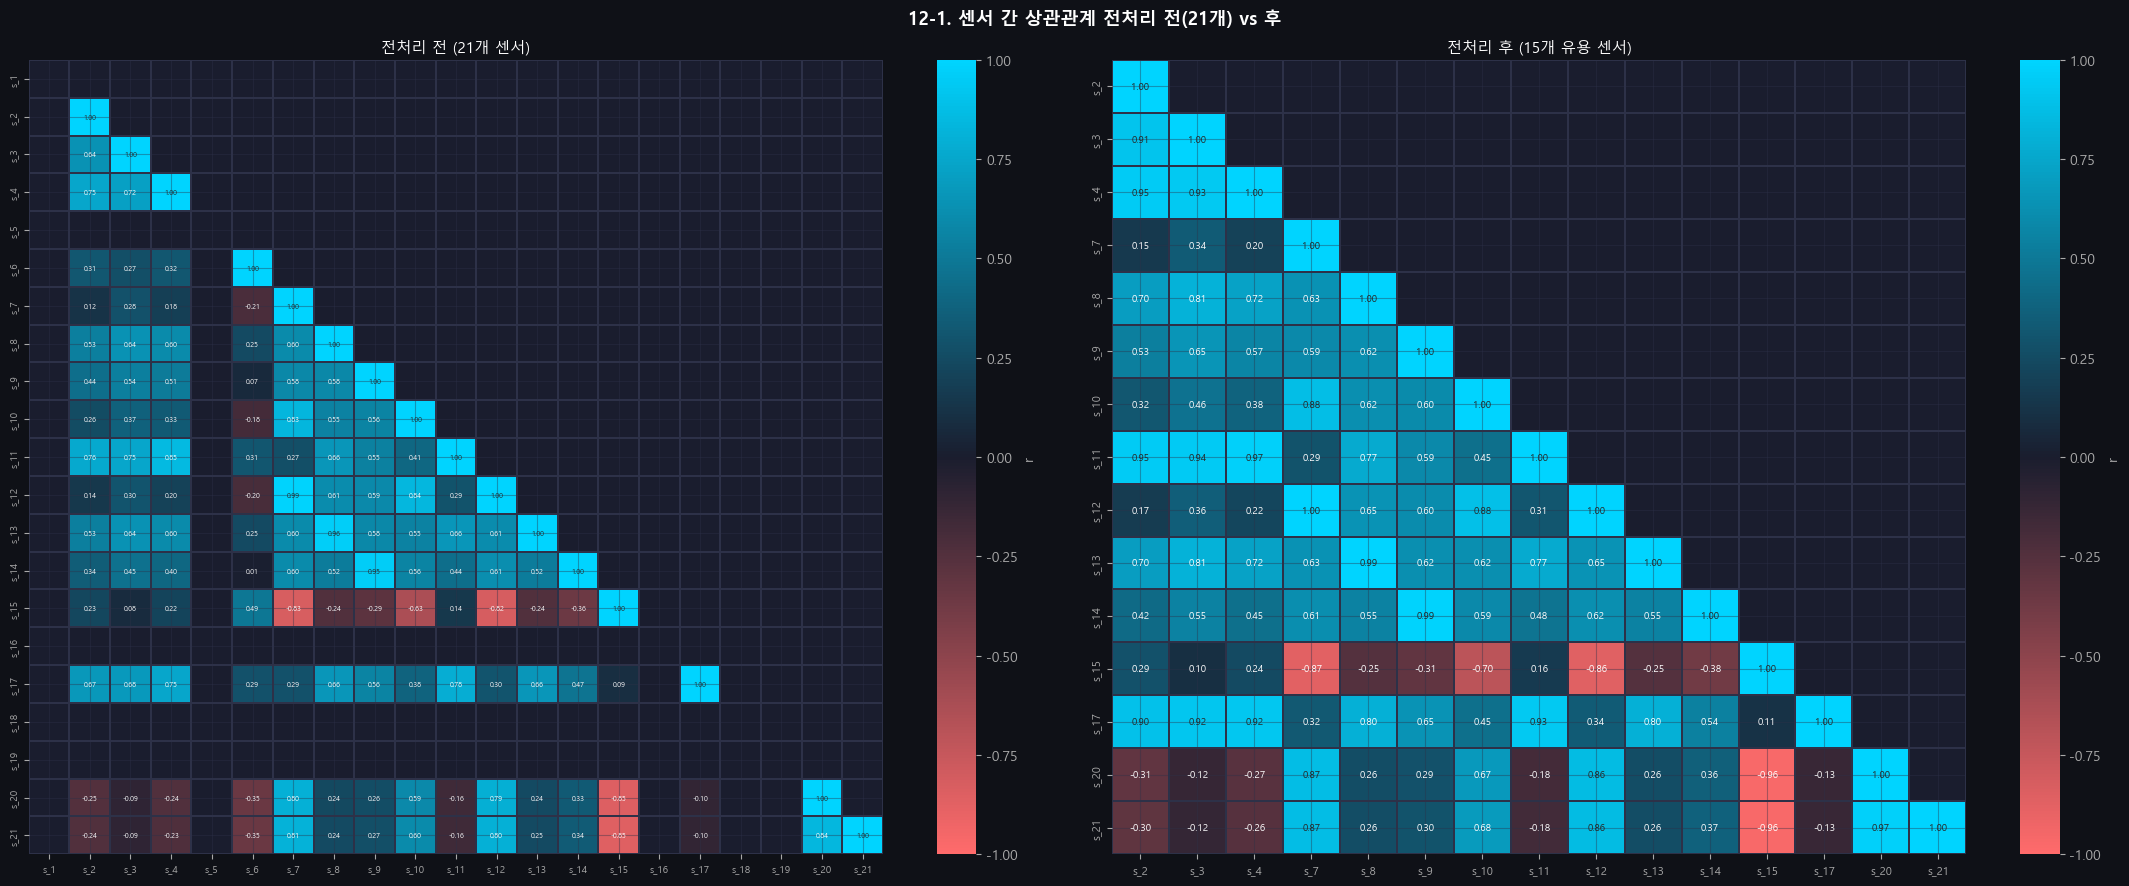

In [20]:
corr_after = train_s4[USEFUL_SENSORS].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('12-1. 센서 간 상관관계 전처리 전(21개) vs 후', fontsize=13, fontweight='bold')

cmap_rg2 = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)
mask_b = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=axes[0], mask=mask_b, cmap=cmap_rg2, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size':5},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label':'r'})
axes[0].set_title(f'전처리 전 (21개 센서)', fontsize=11); axes[0].tick_params(labelsize=7)

mask_a = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(corr_after, ax=axes[1], mask=mask_a, cmap=cmap_rg2, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label':'r'})
axes[1].set_title(f'전처리 후 ({len(USEFUL_SENSORS)}개 유용 센서)', fontsize=11)
axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

### 12-2. Train vs Test 분포 비교 (KS 검정)

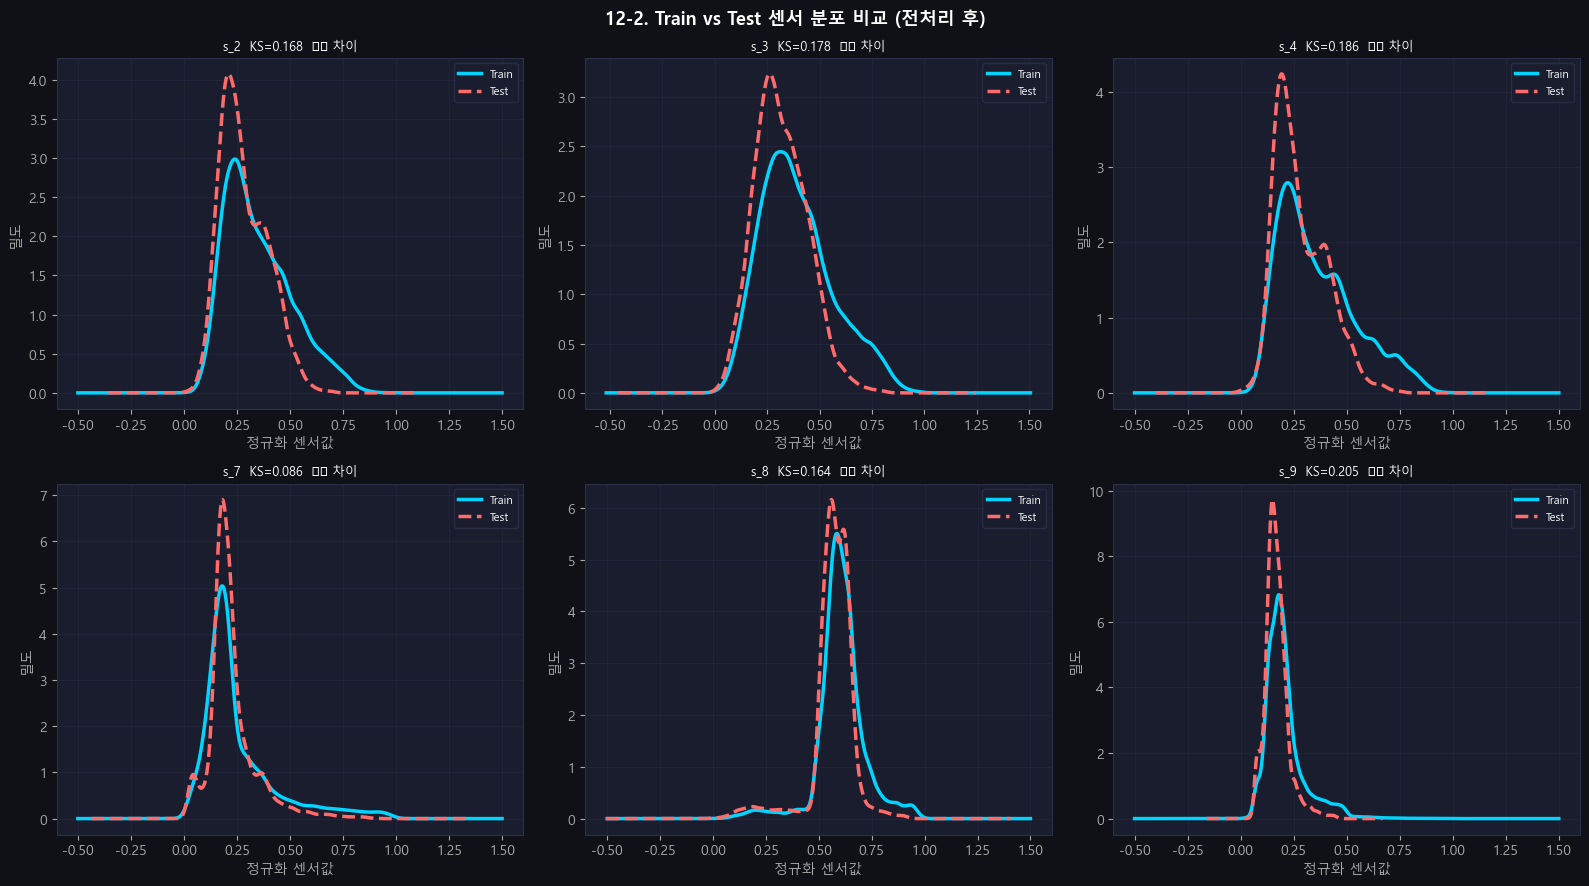

,KS통계량,p-value,판정
센서,,,
s_2,0.1675,0.0,⚠️ 차이
s_3,0.1782,0.0,⚠️ 차이
s_4,0.1858,0.0,⚠️ 차이
s_7,0.0859,0.0,⚠️ 차이
s_8,0.1642,0.0,⚠️ 차이
s_9,0.2053,0.0,⚠️ 차이


In [21]:
show6 = USEFUL_SENSORS[:6]; ks_rows = []
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('12-2. Train vs Test 센서 분포 비교 (전처리 후)', fontsize=13, fontweight='bold')
for ax, s in zip(axes.flat, show6):
    tr_v = train_s4[s].dropna(); te_v = test_s4[s].dropna()
    try: tr_v.plot.kde(ax=ax, color=C[0], lw=2.5, label='Train')
    except: pass
    try: te_v.plot.kde(ax=ax, color=C[1], lw=2.5, ls='--', label='Test')
    except: pass
    ks_stat, ks_p = ks_2samp(tr_v, te_v)
    verdict = '✅ 유사' if ks_p>0.05 else '⚠️ 차이'
    ks_rows.append({'센서':s,'KS통계량':round(ks_stat,4),'p-value':round(ks_p,4),'판정':verdict})
    ax.set_title(f'{s}  KS={ks_stat:.3f}  {verdict}', fontsize=9)
    ax.set_xlabel('정규화 센서값'); ax.set_ylabel('밀도'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.DataFrame(ks_rows).set_index('센서'))

### 12-4. ML 파생변수 다중공선성 (|r| > 0.95)

In [22]:
print(f'=== 12-4. ML 파생변수 다중공선성 (|r|>0.95) — {len(ML_FEATURES)}개 피처 ===')
corr_ml  = subtrain_ml[ML_FEATURES].corr().abs()
upper_ml = corr_ml.where(np.triu(np.ones(corr_ml.shape), k=1).astype(bool))
HIGH_THR = 0.95
high_pairs_ml = (upper_ml.stack().reset_index()
                 .rename(columns={'level_0':'피처A','level_1':'피처B',0:'|r|'})
                 .query('`|r|` >= @HIGH_THR')
                 .sort_values('|r|', ascending=False).reset_index(drop=True))
print(f'|r|≥{HIGH_THR} 쌍: {len(high_pairs_ml)}개 / 전체 {len(ML_FEATURES)*(len(ML_FEATURES)-1)//2}쌍')
if len(high_pairs_ml): display(high_pairs_ml.head(20))
print('→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장')

=== 12-4. ML 파생변수 다중공선성 (|r|>0.95) — 150개 피처 ===
|r|≥0.95 쌍: 721개 / 전체 11175쌍


,피처A,피처B,|r|
0,s_12_lag1,s_12_roll3,0.999996
1,s_7_lag1,s_7_roll3,0.999994
2,s_14_lag1,s_14_roll3,0.999986
3,s_9_lag1,s_9_roll3,0.999984
4,s_12_roll5,s_12_ema5,0.999971
5,s_15_lag1,s_15_roll3,0.999960
6,s_7_roll5,s_7_ema5,0.999959
7,s_10_lag1,s_10_roll3,0.999958
8,s_11_lag1,s_11_roll3,0.999955
9,s_21_lag1,s_21_roll3,0.999936


→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장


---
## 13. CSV 저장 & 최종 요약

In [23]:
import joblib

OUTPUT_DIR = 'preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 파일 경로 ────────────────────────────────────────────────────────────
ml_subtrain_path  = os.path.join(OUTPUT_DIR, 'FD003_nc_ml_subtrain.csv')
ml_valid_path     = os.path.join(OUTPUT_DIR, 'FD003_nc_ml_valid.csv')
ml_test_path      = os.path.join(OUTPUT_DIR, 'FD003_nc_ml_test.csv')
ml_test_eval_path = os.path.join(OUTPUT_DIR, 'FD003_nc_ml_test_eval.csv')
ml_val_eval_path  = os.path.join(OUTPUT_DIR, 'FD003_nc_ml_val_eval.csv')

dl_dir = os.path.join(OUTPUT_DIR, 'dl')
os.makedirs(dl_dir, exist_ok=True)
dl_subtrain_path  = os.path.join(dl_dir, 'FD003_nc_dl_subtrain_long.csv')
dl_valid_path     = os.path.join(dl_dir, 'FD003_nc_dl_valid_long.csv')
dl_test_path      = os.path.join(dl_dir, 'FD003_nc_dl_test_long.csv')
dl_val_eval_path  = os.path.join(dl_dir, 'FD003_nc_dl_val_eval_long.csv')

rul_path          = os.path.join(OUTPUT_DIR, 'FD003_nc_test_RUL.csv')
sensor_scaler_path = os.path.join(OUTPUT_DIR, 'FD003_nc_sensor_scaler.pkl')
ml_scaler_path     = os.path.join(OUTPUT_DIR, 'FD003_nc_ml_scaler.pkl')
ml_feat_path      = os.path.join(OUTPUT_DIR, 'FD003_nc_ml_features.txt')
dl_feat_path      = os.path.join(OUTPUT_DIR, 'FD003_nc_dl_features.txt')

# ── ML CSV 저장 ──────────────────────────────────────────────────────────
subtrain_ml.to_csv(ml_subtrain_path, index=False, encoding='utf-8-sig')
valid_ml.to_csv(ml_valid_path,       index=False, encoding='utf-8-sig')
test_ml.to_csv(ml_test_path,         index=False, encoding='utf-8-sig')
rul_df.to_csv(rul_path,              index=False, encoding='utf-8-sig')

# test_last_ml: 엔진별 마지막 행 + 실제 RUL (unit_nr 오름차순 정렬로 rul_df 순서 일치)
test_last_ml = (test_ml
                .sort_values(['unit_nr', 'time_cycles'])
                .groupby('unit_nr', as_index=False).last()
                .sort_values('unit_nr')
                .reset_index(drop=True))
test_last_ml['RUL'] = rul_df['RUL'].values
test_last_ml.to_csv(ml_test_eval_path, index=False, encoding='utf-8-sig')

# val_eval 저장
val_eval_ml_cols = [c for c in val_eval_ml.columns if c in ['unit_nr','time_cycles'] + ML_FEATURES + ['RUL']]
val_eval_ml[val_eval_ml_cols].to_csv(ml_val_eval_path, index=False, encoding='utf-8-sig')

# ── DL CSV 저장 ──────────────────────────────────────────────────────────
dl_subtrain_long.to_csv(dl_subtrain_path, index=False, encoding='utf-8-sig')
dl_valid_long.to_csv(dl_valid_path,       index=False, encoding='utf-8-sig')
dl_test_long.to_csv(dl_test_path,         index=False, encoding='utf-8-sig')
dl_val_eval_long.to_csv(dl_val_eval_path, index=False, encoding='utf-8-sig')

# ── 모델/스케일러/피처 저장 ──────────────────────────────────────────────
joblib.dump(sensor_scaler, sensor_scaler_path)
joblib.dump(ml_scaler,     ml_scaler_path)
with open(ml_feat_path, 'w', encoding='utf-8') as f:
    for col in ['unit_nr', 'time_cycles'] + ML_FEATURES + ['RUL']:
        f.write(f'{col}\n')
with open(dl_feat_path, 'w', encoding='utf-8') as f:
    for col in DL_FEATURES:
        f.write(f'{col}\n')

# ── 최종 요약 ────────────────────────────────────────────────────────────
n_val_eval_samples = dl_val_eval_long['sample_id'].nunique() if 'sample_id' in dl_val_eval_long.columns and len(dl_val_eval_long) > 0 else 0

print('=' * 74)
print('  FD003 ML / DL 통합 전처리 파이프라인 완료')
print('=' * 74)
print()
print('■ 공통 파이프라인')
print('  센서 제거(STD + FD003 override) → RUL Cap=125')
print('  → Gaussian(σ=2) → Validation 분리(80:20)')

print()
print('■ FD003 No-Clustering — fault_mode_cluster 미사용')

print()
print('■ ML 분기 — 파생변수 생성 후 ML 전체 feature MinMax 정규화')
ml_summary = pd.DataFrame({
    '구분'      : ['Sub-train', 'Validation', 'Test(전체)', 'Test(평가용)', 'val_eval'],
    'shape'     : [str(subtrain_ml.shape), str(valid_ml.shape), str(test_ml.shape),
                   str(test_last_ml.shape), str(val_eval_ml.shape)],
    'ML피처 수' : [len(ML_FEATURES)] * 5,
    '파일'      : ['FD003_nc_ml_subtrain.csv', 'FD003_nc_ml_valid.csv', 'FD003_nc_ml_test.csv',
                   'FD003_nc_ml_test_eval.csv', 'FD003_nc_ml_val_eval.csv'],
}).set_index('구분')
display(ml_summary)

print()
print('■ DL 분기 — 센서 MinMax 정규화 후 슬라이딩 윈도우 Long Format')
dl_summary = pd.DataFrame({
    '구분'       : ['Sub-train', 'Validation', 'Test', 'val_eval'],
    'shape'      : [str(dl_subtrain_long.shape), str(dl_valid_long.shape),
                    str(dl_test_long.shape),      str(dl_val_eval_long.shape)],
    '샘플 수'    : [X_subtrain_dl.shape[0], X_valid_dl.shape[0],
                    X_test_dl.shape[0],      n_val_eval_samples],
    'window_size': [WINDOW_SIZE] * 4,
    'DL피처 수'  : [len(DL_FEATURES)] * 4,
    '파일(dl/)'  : ['FD003_nc_dl_subtrain_long.csv', 'FD003_nc_dl_valid_long.csv',
                    'FD003_nc_dl_test_long.csv',     'FD003_nc_dl_val_eval_long.csv'],
}).set_index('구분')
display(dl_summary)

print()
print(f'📄 저장 경로: {os.path.abspath(OUTPUT_DIR)}/')
print(f'   - Sensor scaler: {os.path.basename(sensor_scaler_path)}')
print(f'   - ML scaler    : {os.path.basename(ml_scaler_path)}')
print()
print('── ML 활용법 ──')
print('  subtrain = pd.read_csv("FD003_nc_ml_subtrain.csv")')
print('  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])')
print()
print('── DL 활용법 (Long Format → 3D 복원) ──')
print('  df  = pd.read_csv("dl/FD003_nc_dl_subtrain_long.csv")')
print('  grp = df.groupby("sample_id")')
print('  X   = np.stack([grp.get_group(i)[DL_FEATURES].values')
print('                  for i in range(df["sample_id"].nunique())])  # (N, 30, F)')
print('  y   = df.groupby("sample_id")["RUL"].last().values')


  FD003 ML / DL 통합 전처리 파이프라인 완료

■ 공통 파이프라인
  센서 제거(STD + FD003 override) → RUL Cap=125
  → Gaussian(σ=2) → Validation 분리(80:20)

■ FD003 No-Clustering — fault_mode_cluster 미사용

■ ML 분기 — 파생변수 생성 후 ML 전체 feature MinMax 정규화


,shape,ML피처 수,파일
구분,,,
Sub-train,"(19612, 156)",150,FD003_nc_ml_subtrain.csv
Validation,"(4608, 156)",150,FD003_nc_ml_valid.csv
Test(전체),"(16096, 155)",150,FD003_nc_ml_test.csv
Test(평가용),"(100, 156)",150,FD003_nc_ml_test_eval.csv
val_eval,"(20, 153)",150,FD003_nc_ml_val_eval.csv



■ DL 분기 — 센서 MinMax 정규화 후 슬라이딩 윈도우 Long Format


,shape,샘플 수,window_size,DL피처 수,파일(dl/)
구분,,,,,
Sub-train,"(530760, 20)",17692,30,15,FD003_nc_dl_subtrain_long.csv
Validation,"(123840, 20)",4128,30,15,FD003_nc_dl_valid_long.csv
Test,"(410880, 20)",13696,30,15,FD003_nc_dl_test_long.csv
val_eval,"(600, 18)",20,30,15,FD003_nc_dl_val_eval_long.csv



📄 저장 경로: c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\preprocessed/
   - Sensor scaler: FD003_nc_sensor_scaler.pkl
   - ML scaler    : FD003_nc_ml_scaler.pkl

── ML 활용법 ──
  subtrain = pd.read_csv("FD003_nc_ml_subtrain.csv")
  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])

── DL 활용법 (Long Format → 3D 복원) ──
  df  = pd.read_csv("dl/FD003_nc_dl_subtrain_long.csv")
  grp = df.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df["sample_id"].nunique())])  # (N, 30, F)
  y   = df.groupby("sample_id")["RUL"].last().values
